In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

from data.scripts.shared.text_metrics import compute_author_metrics
import nltk

from scipy import stats

from sklearn.feature_extraction.text import CountVectorizer

from corus import load_taiga_nplus1, load_taiga_nplus1_metas

/Users/pgdev/PycharmProjects/rubert_author_attribution/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/pgdev/PycharmProjects/rubert_author_attribution/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
path = ''
metas = load_taiga_nplus1_metas(path)
records = load_taiga_nplus1(path, metas)
next(records)

TaigaRecord(
    id='20150302chaotic',
    meta=Meta(
        id='20150302chaotic',
        timestamp=datetime.datetime(2015, 3, 2, 17, 53),
        tags=None,
        themes=None,
        rubric='Наука',
        genre=None,
        topic=None,
        author=Author(
            name='AZ ZAZ',
            readers=None,
            texts=None,
            profession=None,
            about=None,
            url=None
        ),
        lang=None,
        title='Физики поделили экономики на «ламинарные» и «хаотические»',
        url='https://nplus1.ru/news/2015/03/02/chaotic'
    ),
    text='\nУченые из Университета Сапиенца в Риме предложили метод классификации стран в соответствии с типом их экономики. Метод позволяет сказать, насколько поведение страны поддается прогнозу и соответствует ли оно «ламинарному» или «хаотическому» типу развития. Работа опубликована\xa0в журнале PLoS ONE, кратко о ней можнопрочитать\xa0на сайте Nature. Главной задачей исследования был поиск метрики, которая

In [4]:
from copy import deepcopy
recs = []
c = 0
for r in records:
    _r = {
        'author': r.meta.author.name,
        'text': r.text,
    }
    recs.append(deepcopy(_r))

df = pd.DataFrame(recs)

In [5]:
df.head()

,author,text
0,AZ ZAZ,\nСотрудники Венского медицинского университет...
1,AZ ZAZ,\nСотрудники Массачусетского технологического ...
2,AZ ZAZ,\nАмерикано-немецкая группа исследователей обн...
3,AZ ZAZ,\nКрупная международная коллаборация исследова...
4,AZ ZAZ,\nХимики из Университета Хэбей в Китае рассчит...


In [6]:
df.to_csv('npl1.csv', index=False)

In [7]:
MLFLOW_TRACKING_URI = "http://localhost:2000"
MLFLOW_EXPERIMENT_NAME = "npl1_metrics_analysis"
MLFLOW_RUN_NAME = "first run"

DF_PATH_NAME = ""

METRICS_LIST = [
    'avg_sent_len_words',
    'avg_word_len_chars',

    'mtld',

    'avg_tree_depth',
    'passive_ratio',
    'func_word_ratio',
    'avg_clauses_per_sent',
    'noun_verb_ratio',

    'compression_ratio',

    'flesch_reading_ease',
    'gunning_fog',
]
RANDOM_STATE = 67

In [8]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
mlflow.start_run(run_name=MLFLOW_RUN_NAME)
mlflow.log_param("dataset_name", 'npl1.csv')


2026/05/06 23:18:10 INFO mlflow.tracking.fluent: Experiment with name 'npl1_metrics_analysis' does not exist. Creating a new experiment.


'npl1.csv'

In [9]:
df = pd.read_csv(DF_PATH_NAME, delimiter=',')
df.columns=["author","text"]
df.head()

,author,text
0,AZ ZAZ,\nСотрудники Венского медицинского университет...
1,AZ ZAZ,\nСотрудники Массачусетского технологического ...
2,AZ ZAZ,\nАмерикано-немецкая группа исследователей обн...
3,AZ ZAZ,\nКрупная международная коллаборация исследова...
4,AZ ZAZ,\nХимики из Университета Хэбей в Китае рассчит...


In [10]:
category_group = df.groupby(['author'])
grouped = df['author'].value_counts()

grouped

author
Василий Сычев            1851
Николай Воронцов         1577
Владимир Королев          924
Олег Лищук                618
Кристина Уласович         578
Екатерина Русакова        316
Даниил Кузнецов           308
Тарас Молотилин           306
Роман Фишман              193
Александр Ершов           174
Александр Березин         132
Соня Долотовская          121
Александр Еникеев         114
Евгений Анохин             77
Андрей Коняев              75
Екатерина Митрофанова      63
Анна Образцова             42
Александра Стуккей         40
AZ ZAZ                     29
Надежда Бессонова          29
Юлия Минц                  27
Анна Маньшина              16
Админ Админов              10
Дмитрий Иванов             10
Екатерина Корзенева         8
Екатерина  Жданова          7
Аня Савченко                6
Азим Missarov               5
Артем Коржиманов            5
Александр Войтюк            5
Марат Мусин                 4
Игорь Иванов                3
Роман Переборщиков          1
Nam

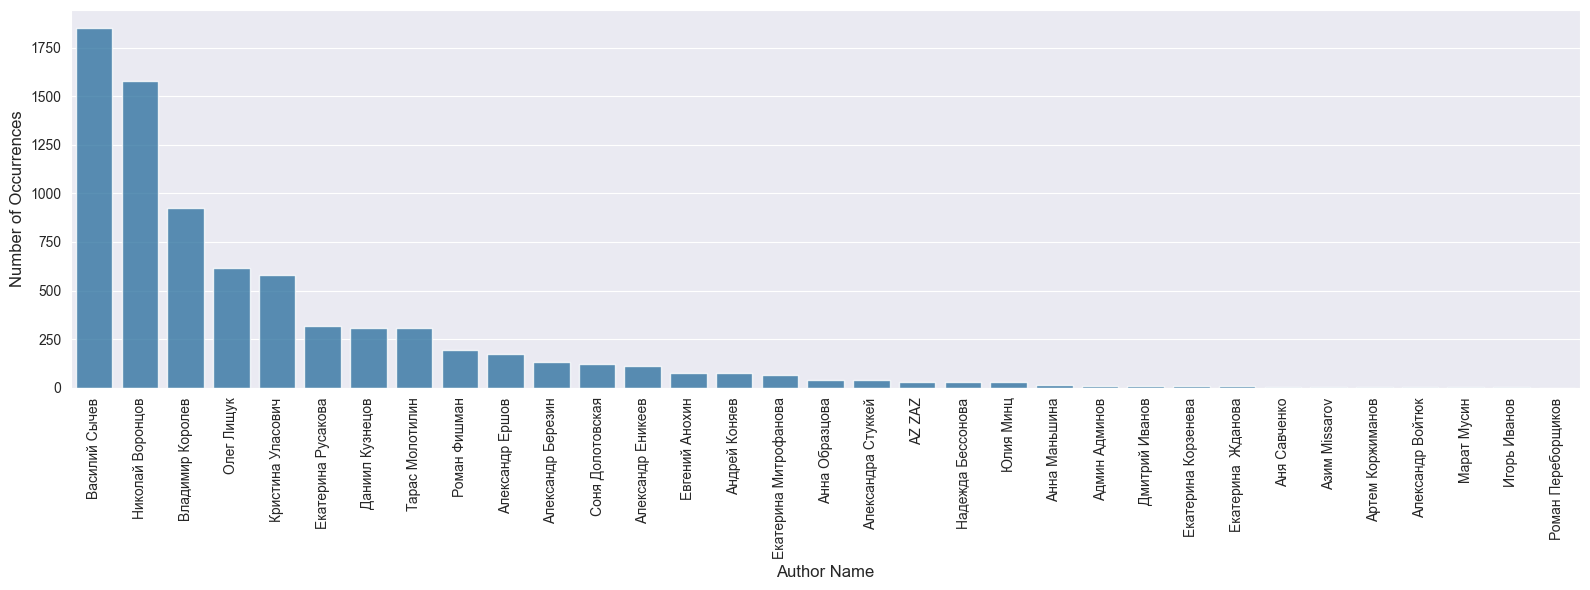

In [11]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(grouped, alpha=0.8, ax=ax)
ax.set_ylabel('Number of Occurrences', fontsize=12)
ax.set_xlabel('Author Name', fontsize=12)
ax.tick_params(axis='x', rotation=90)
fig.tight_layout()

In [12]:
mlflow.log_figure(fig, "plots/author_comments_count.png")

In [13]:
import re
import validators
re_id = re.compile(r'id\d+')

def preprocess_text(text: str) -> str | None:
    """
    Препроцессинг с учётом источника текста.
    Разные источники требуют разной очистки.

    source: 'literature', 'science_pop', 'social_media'
    """

    splited = text.split()
    result = []

    for item in splited:
        if 'id' in text:
            pass

        if re_id.search(item):
            continue

        if validators.url(item):
            continue
        if validators.email(item):
            continue

        _item = item.replace('\xa0', '')
        _item = _item.replace('\\n', '')
        result.append(_item)

    text = ' '.join(result).strip()

    if not text:
        return None

    # Общая очистка для всех источников
    text = re.sub(r'\s+', ' ', text)       # множественные пробелы → один
    text = re.sub(r'\n{3,}', '\n\n', text) # больше двух переносов → два
    text = text.strip()

    # НЕ трогаем пунктуацию и стиль — это часть авторского голоса
    text = re.sub(r'http\S+|www\S+', '', text)        # ссылки
    text = re.sub(r'@\w+', '', text)                   # упоминания
    text = re.sub(r'#\w+', '', text)                   # хэштеги
    #text = re.sub(r'[^\w\s.,!?;:\-—«»"\'()\n]', '', text)  # эмодзи и спецсимволы

    # Для литературы убираем колонтитулы и служебные пометы
    text = re.sub(r'^Глава \w+\.?\s*', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\d+\s*$', '', text, flags=re.MULTILINE)  # номера страниц


    text = re.sub(r'\[\d+\]', '', text)  # [1], [23] — ссылки на источники
    text = re.sub(r'^#{1,6}\s+', '', text, flags=re.MULTILINE)  # заголовки markdown

    # Финальная проверка — убираем пустые строки в середине
    text = re.sub(r'\n\s*\n', '\n\n', text)

    return text.strip()

In [14]:
df["text"] = df["text"].apply(
    lambda x:
    preprocess_text(x)
)

In [15]:
from joblib import Parallel, delayed

author_metrics = Parallel(n_jobs=3)(
    delayed(compute_author_metrics)(group, author)
    for author, group in df.groupby("author")
)

author_df = pd.DataFrame(author_metrics).set_index("author")

/Users/pgdev/PycharmProjects/rubert_author_attribution/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/pgdev/PycharmProjects/rubert_author_attribution/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/pgdev/PycharmProjects/rubert_author_attribution/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to t

In [17]:
author_df.head()

,text_count,token_count_mean,token_count_median,token_count_std,token_count_min,token_count_max,token_count_q25,token_count_q75,type_count_mean,type_count_median,...,repeated_punct_count_max,repeated_punct_count_q25,repeated_punct_count_q75,url_count_mean,url_count_median,url_count_std,url_count_min,url_count_max,url_count_q25,url_count_q75
author,,,,,,,,,,,,,,,,,,,,,
AZ ZAZ,29,237.6552,237.0,101.0316,37.0,449.0,179.00,310.00,177.4483,171.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Админ Админов,10,246.2000,243.0,109.4296,94.0,394.0,162.25,345.25,177.7000,168.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Азим Missarov,5,295.2000,304.0,134.1965,151.0,468.0,175.00,378.00,192.6000,164.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Александр Березин,132,308.5682,296.0,128.9250,45.0,688.0,223.75,389.75,224.9773,221.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Александр Войтюк,5,253.0000,253.0,90.4931,148.0,384.0,194.00,286.00,185.8000,180.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
author_df.to_csv("npl1_author_metrics.csv")

In [19]:
dataset = mlflow.data.from_pandas(author_df, name="metrics_df")

mlflow.log_input(dataset, context="metrics_df")

/Users/pgdev/PycharmProjects/rubert_author_attribution/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [20]:
mlflow.log_artifact("npl1_author_metrics.csv", artifact_path="data")

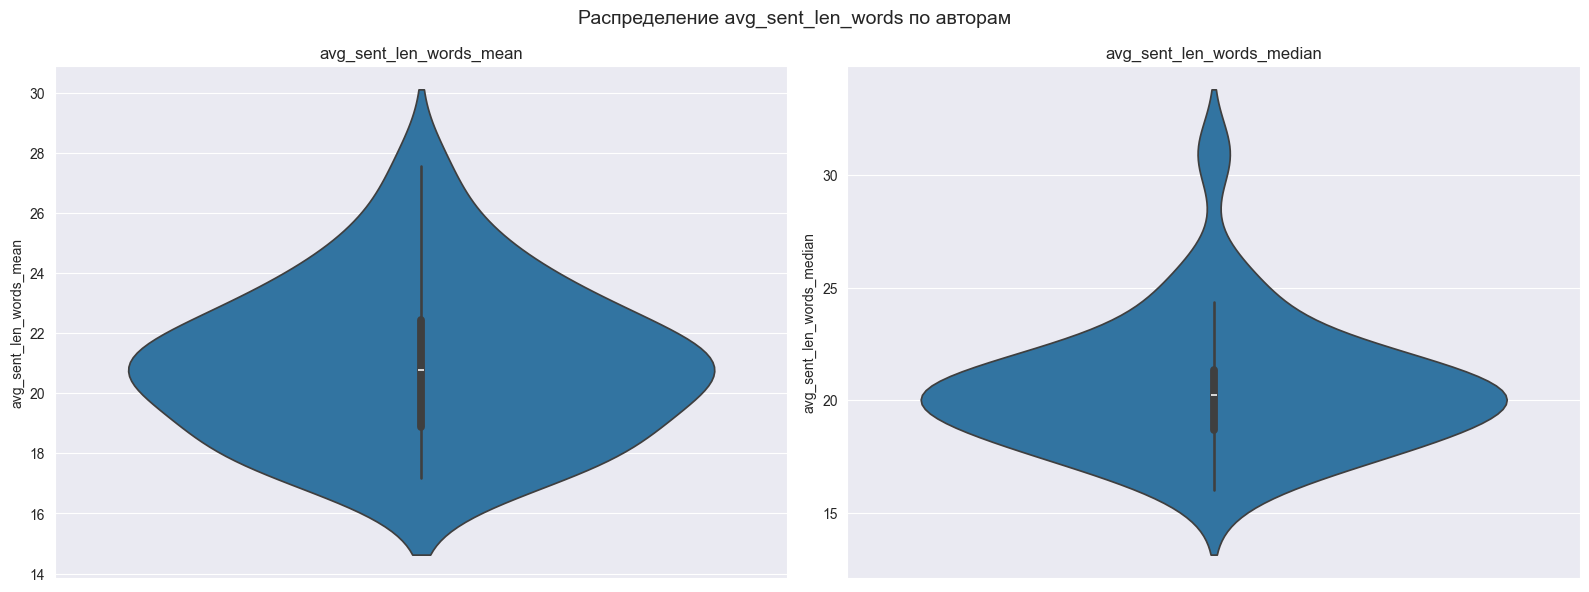

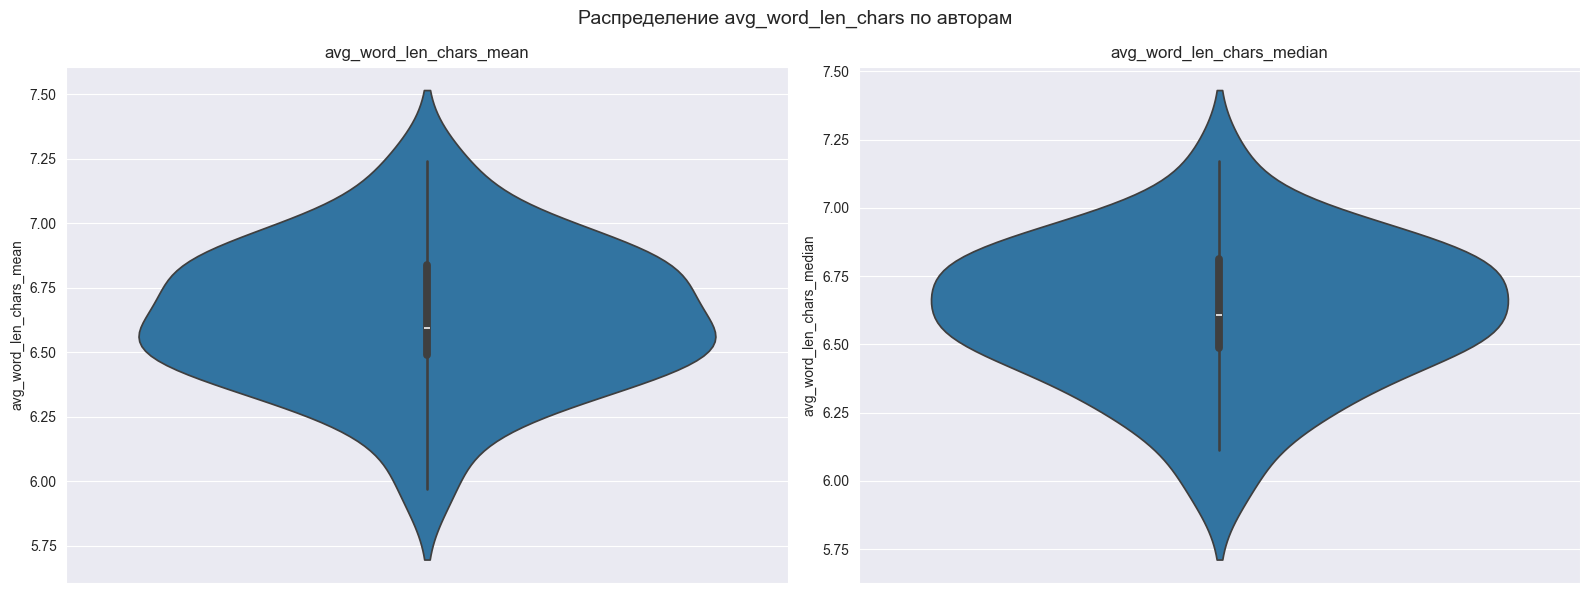

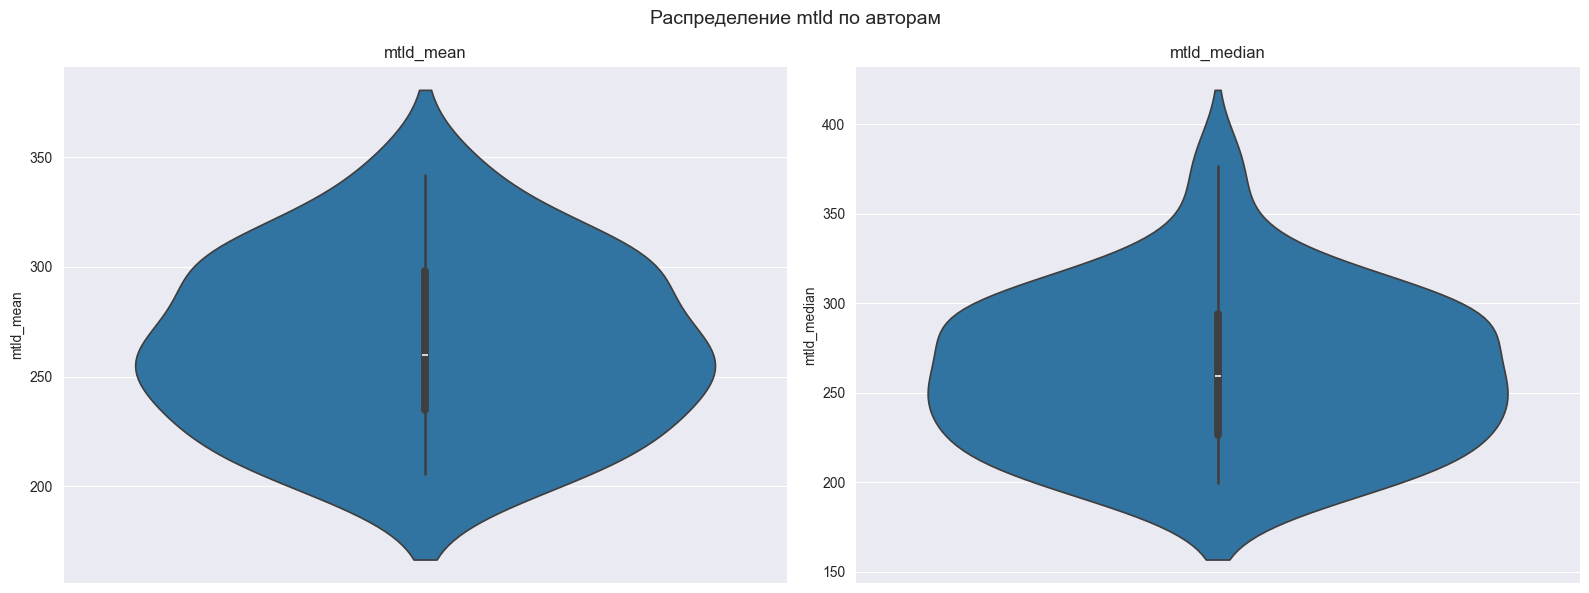

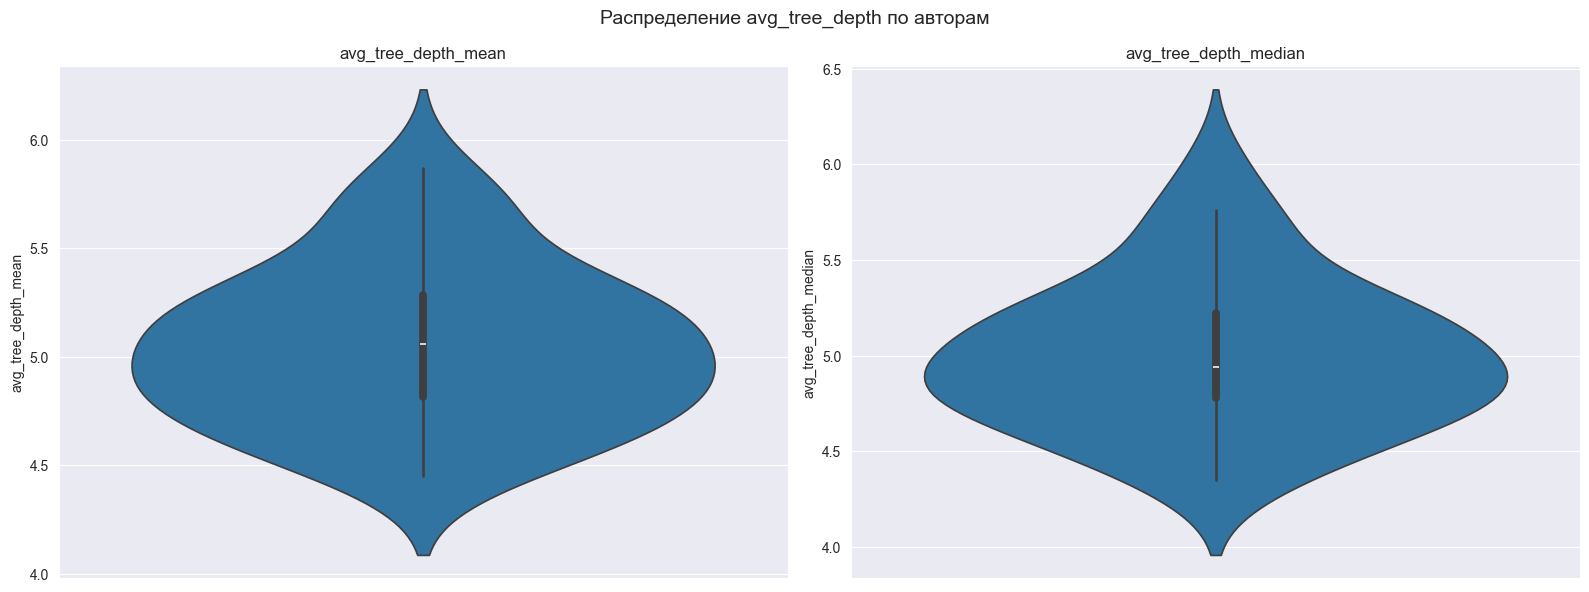

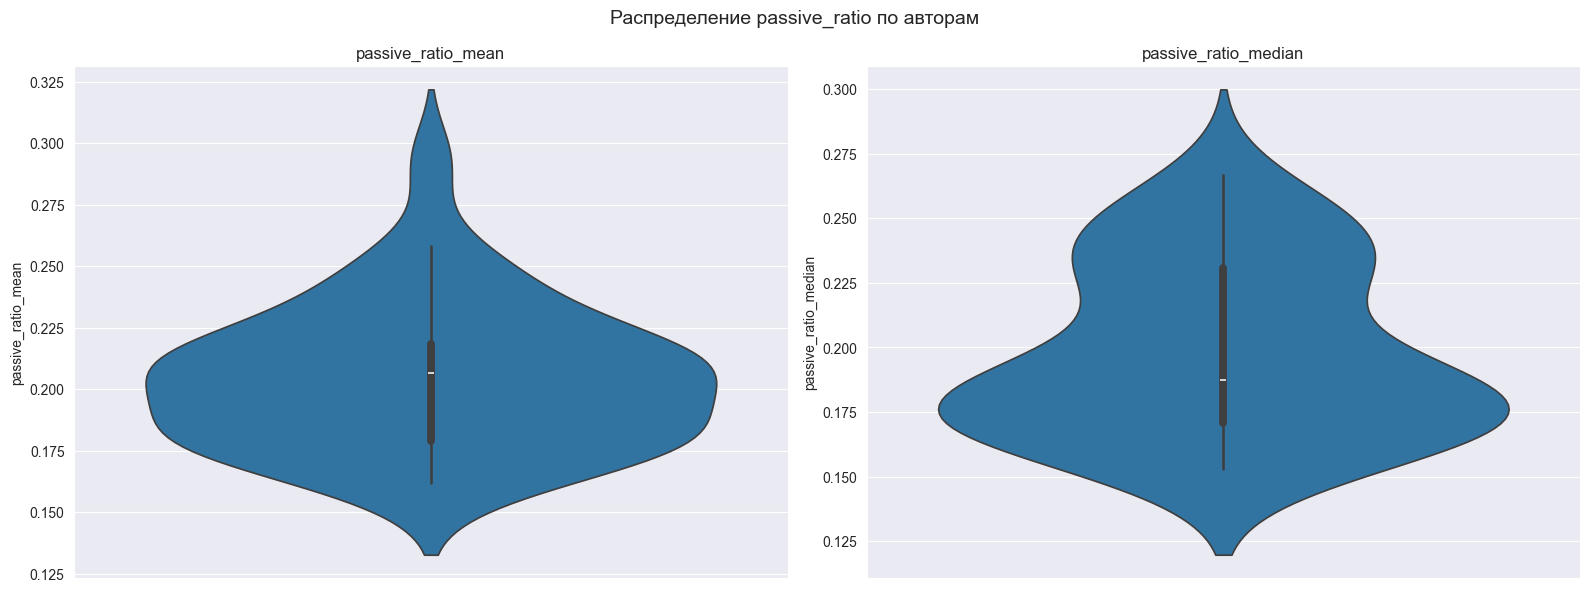

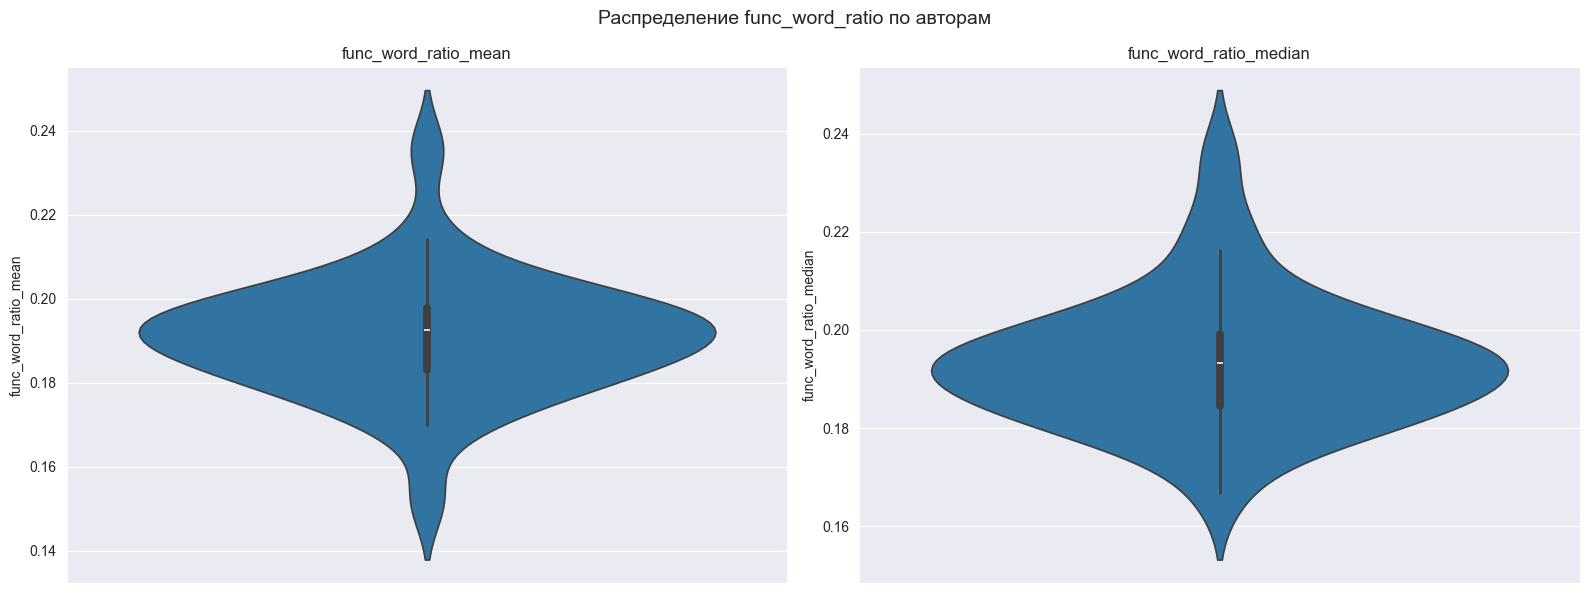

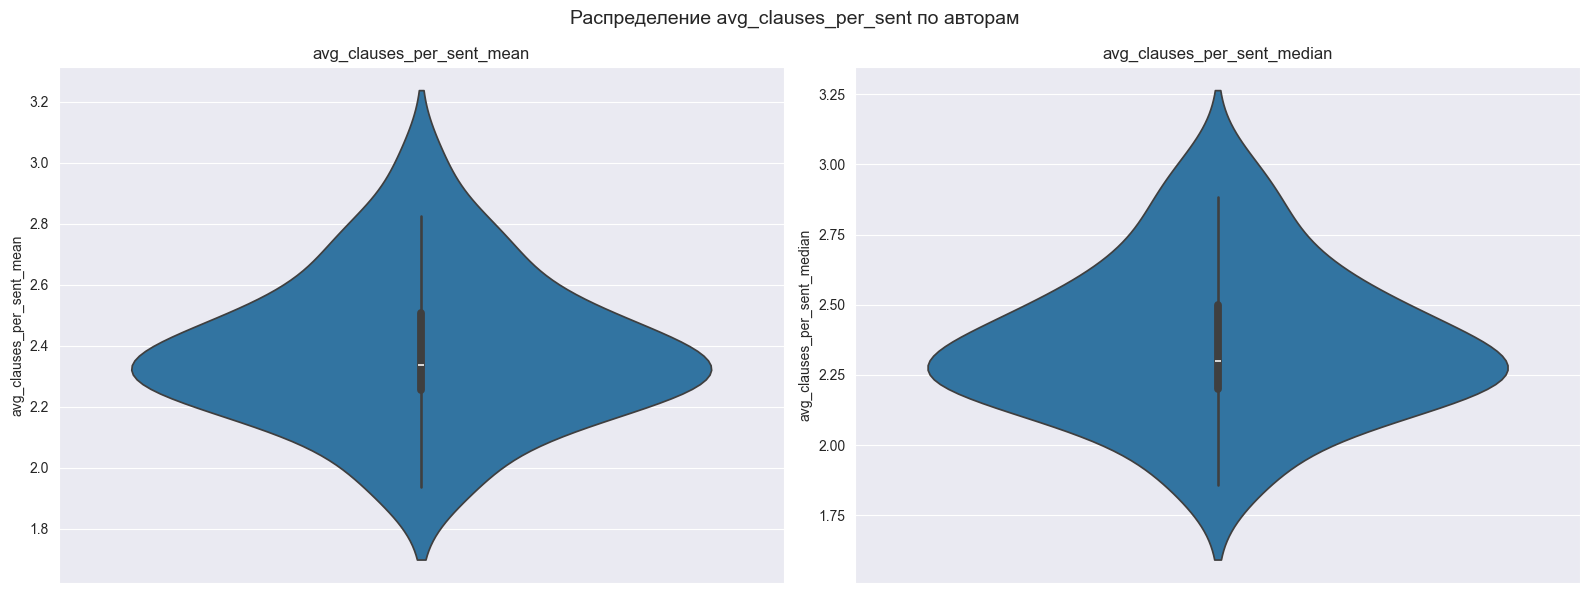

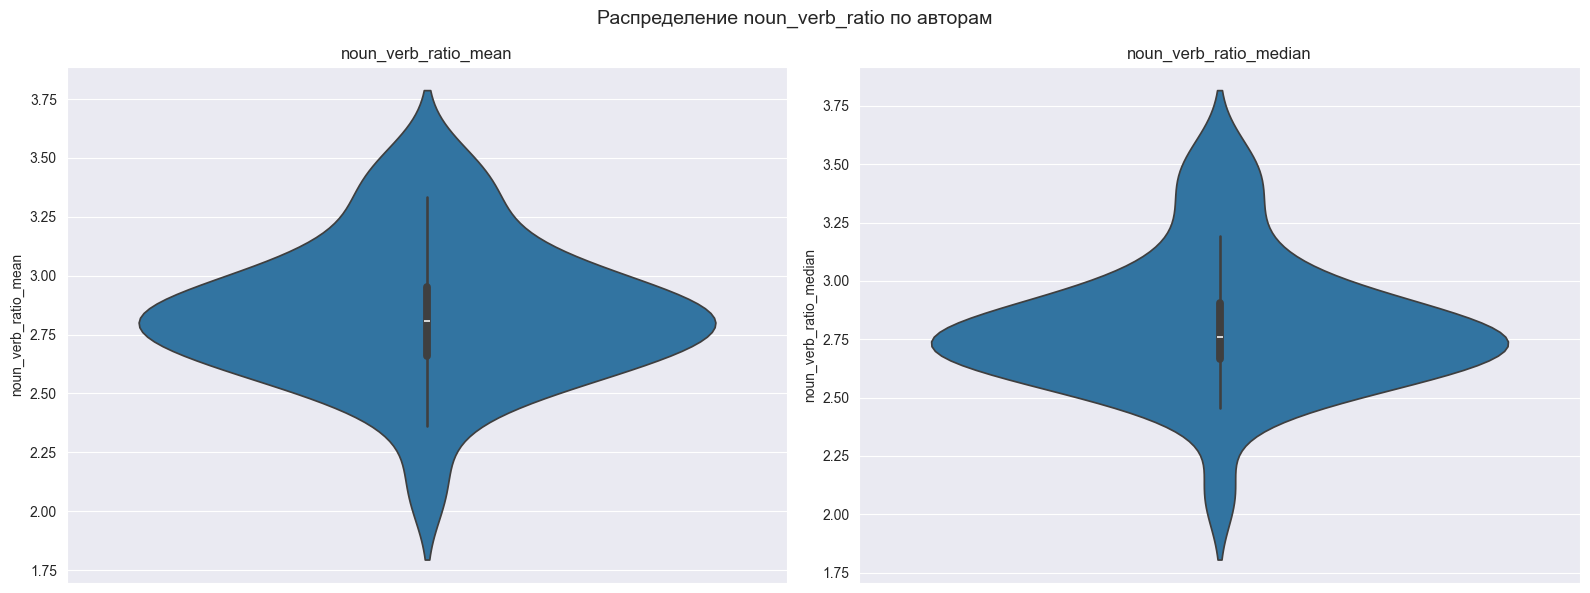

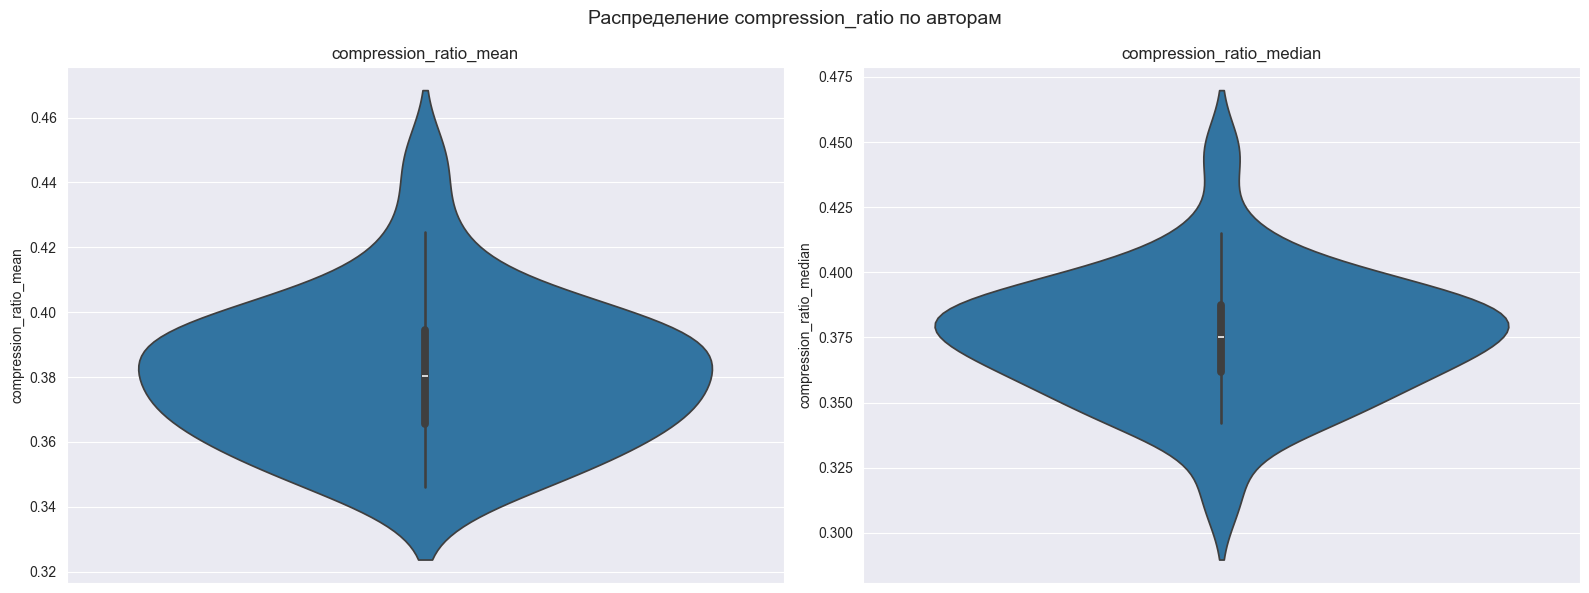

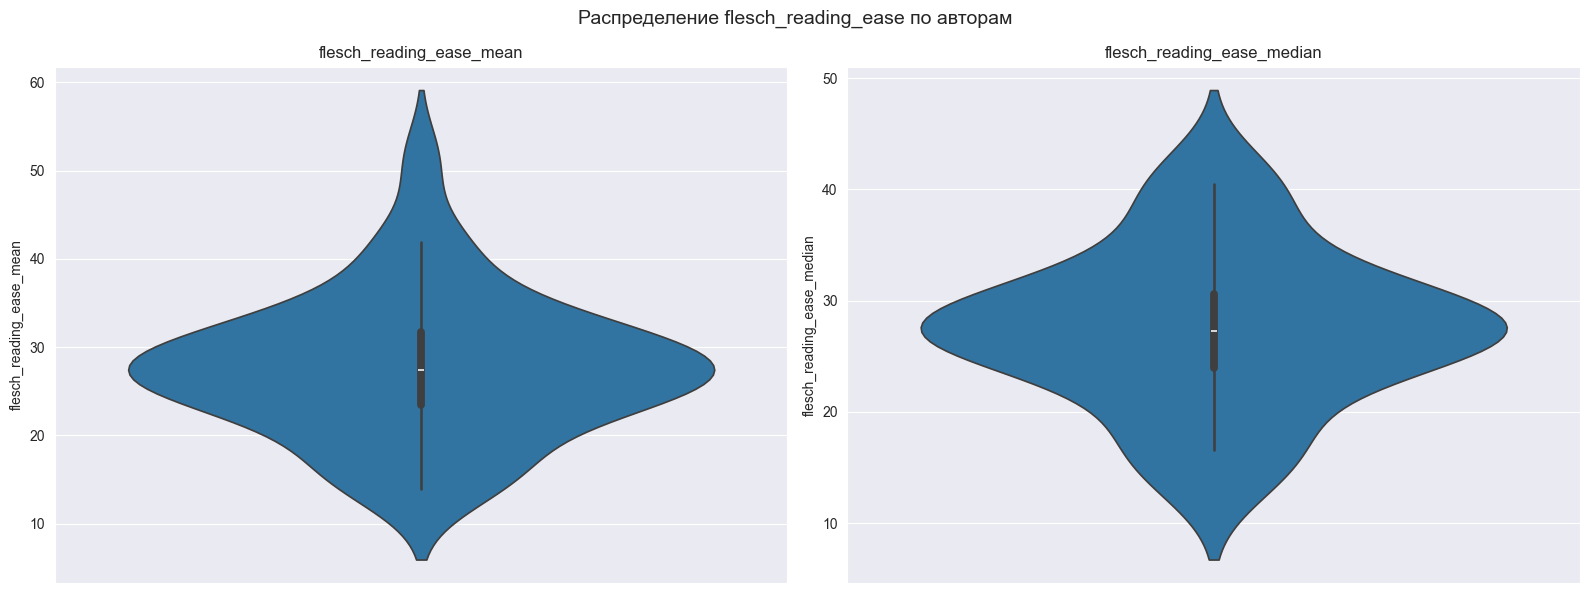

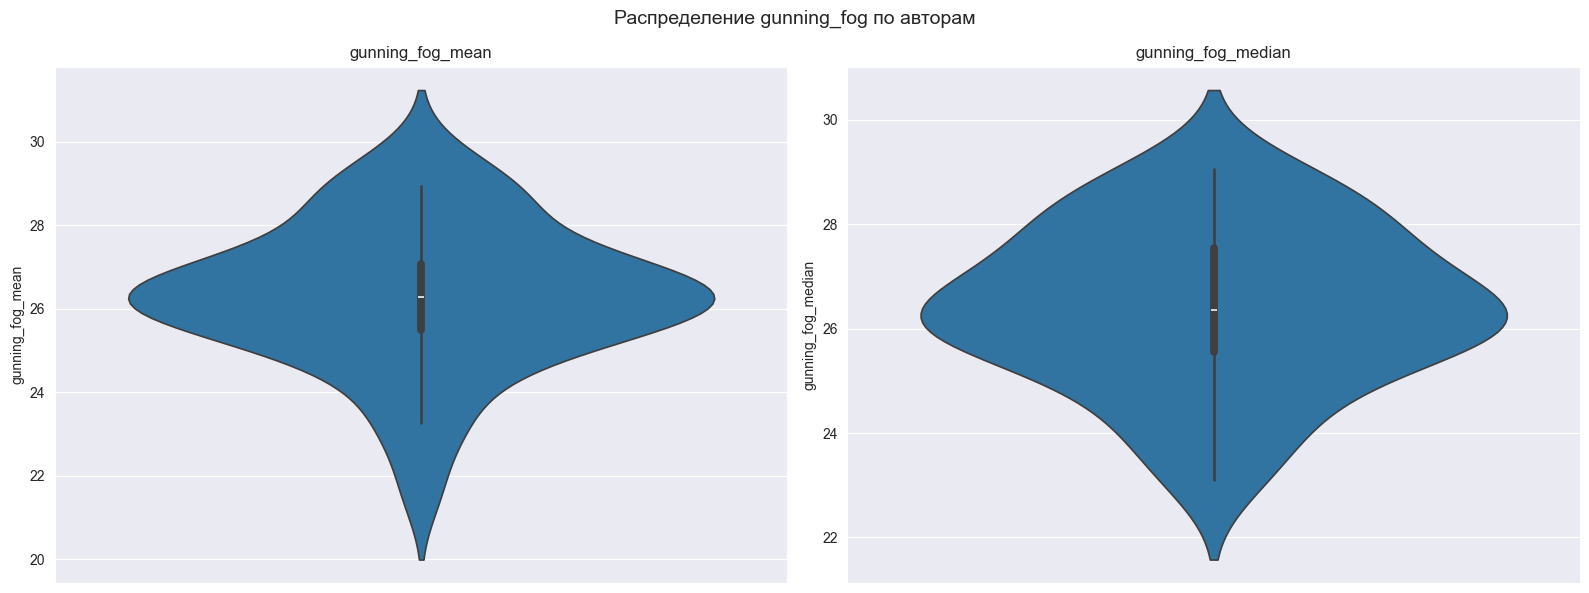

In [21]:
for metric in METRICS_LIST:
    col_mean = f'{metric}_mean'
    col_median = f'{metric}_median'

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.violinplot(data=author_df, y=col_mean, ax=axes[0])
    axes[0].set_title(col_mean)
    sns.violinplot(data=author_df, y=col_median, ax=axes[1])
    axes[1].set_title(col_median)

    fig.suptitle(f'Распределение {metric} по авторам', fontsize=14)
    fig.tight_layout()

    display(fig)
    mlflow.log_figure(fig, f"plots/{metric}_violin.png")
    plt.close(fig)

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

def create_author_similarity_matrix(df, ngram_range):
    """
    Создать матрицу сходства между авторами на основе их n-грамм
    """
    # Создаем корпус текстов для каждого автора
    author_texts = []
    authors = df['author'].unique()

    for author in authors:
        try:
            author_text = ' '.join([str(x) for x in df[df['author'] == author]['text'].tolist()])
            author_texts.append(author_text)
        except:
            print(author)

    # Векторизуем n-граммы
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=500)
    ngram_matrix = vectorizer.fit_transform(author_texts)

    # Вычисляем косинусное сходство
    similarity_matrix = cosine_similarity(ngram_matrix)

    return similarity_matrix, authors

sample_df = df.groupby('author').sample(n=50, replace=True, random_state=RANDOM_STATE)
sample_df.head()

,author,text
3,AZ ZAZ,Крупная международная коллаборация исследовате...
30,AZ ZAZ,Группа ученых из Германии и Японии впервые пол...
10,AZ ZAZ,Психологи из Университета МакГилла в Канаде об...
5,AZ ZAZ,"Немецкие ученые обнаружили ген, который участв..."
7,AZ ZAZ,Ученые из Северо-Западного Университета в США ...


Text(0.5, 1.0, 'Сходство авторов на основе n-грамм')

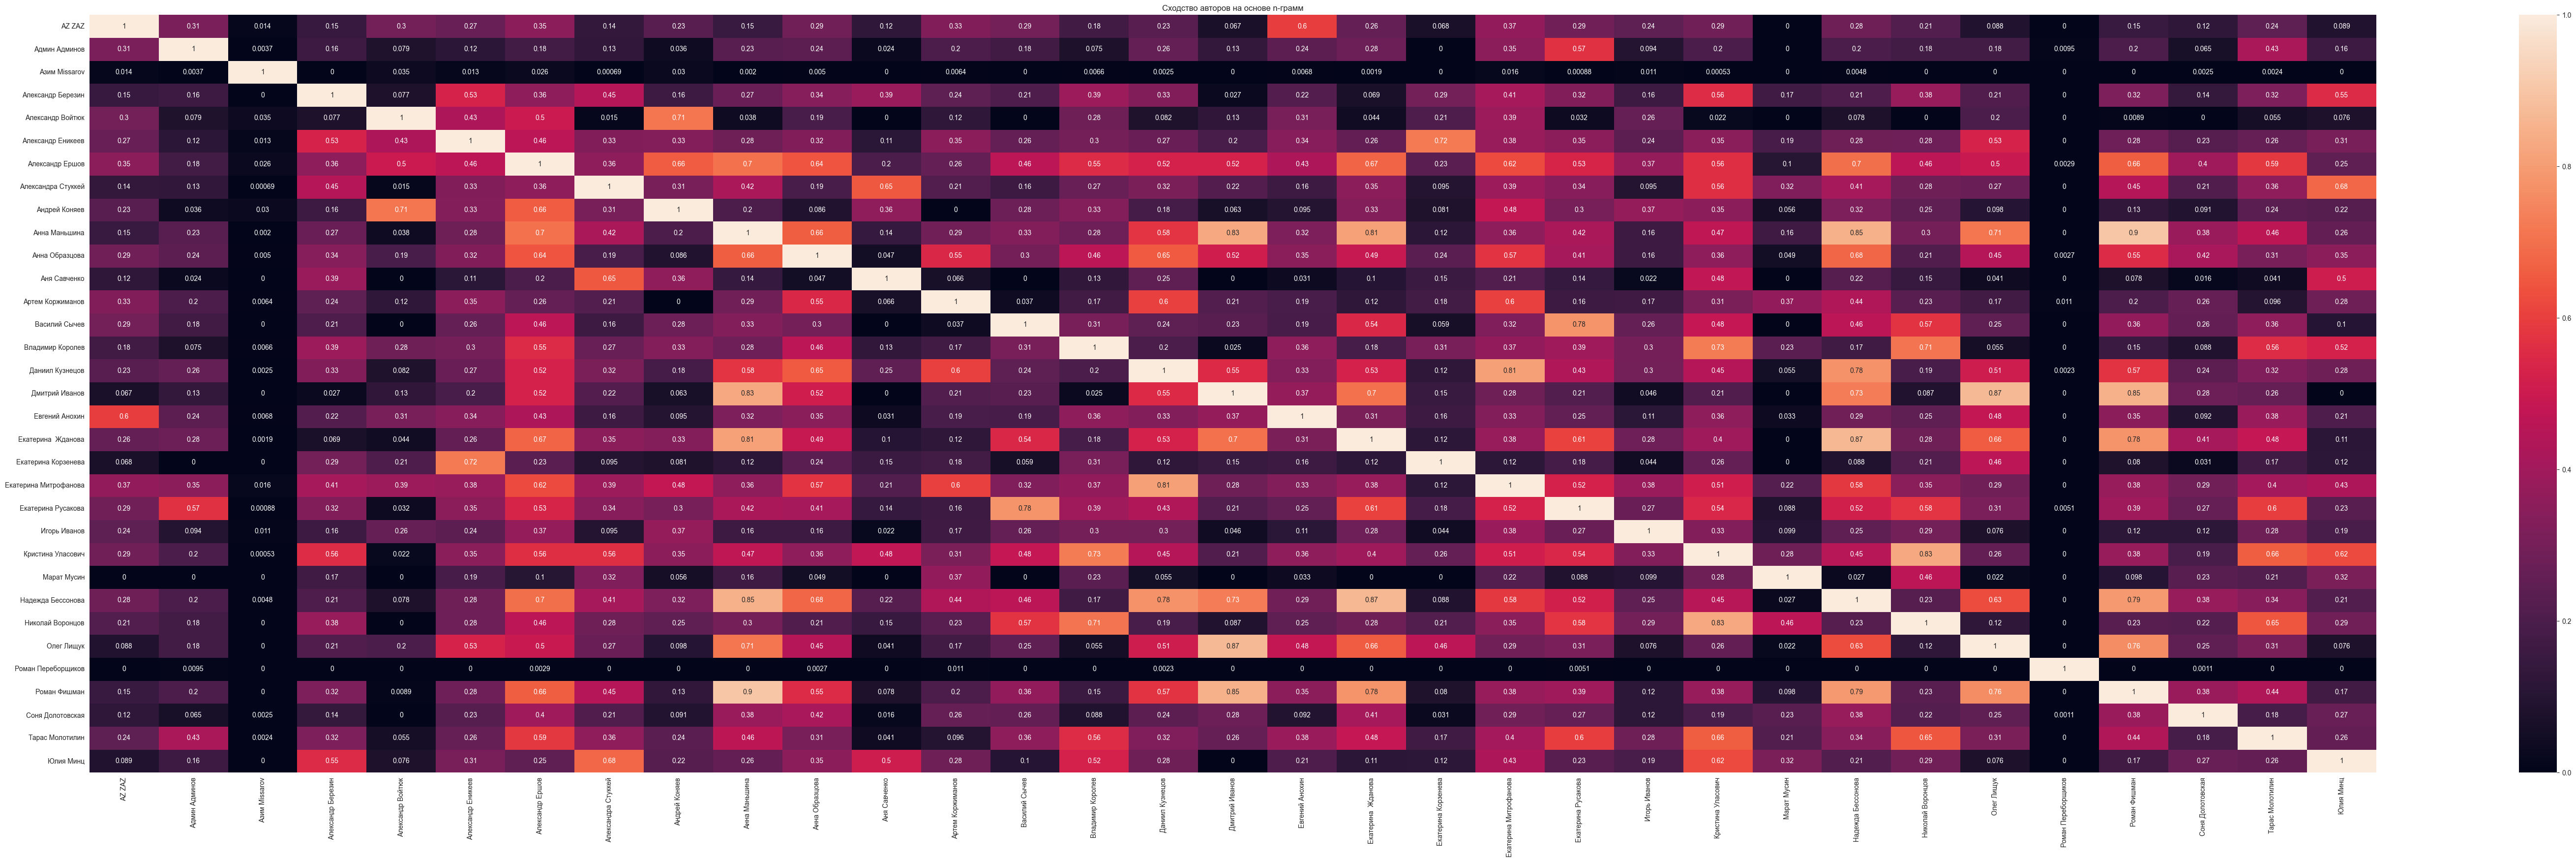

In [30]:
similarity_matrix, authors = create_author_similarity_matrix(sample_df, (3,5))

fig, ax = plt.subplots(figsize=(75, 20))
sns.heatmap(similarity_matrix,
            xticklabels=authors,
            yticklabels=authors,
            annot=True,
            vmin=0, vmax=1)
ax.set_title('Сходство авторов на основе n-грамм')

In [31]:
mlflow.log_figure(fig, f"plots/sim_matrix_3_5_ngrams.png")

In [32]:
def get_top_ngrams_by_author(df, ngram_range, top_k):
    author_ngrams = {}

    for author in df['author'].unique():

        author_texts = ' '.join([str(x) for x in df[df['author'] == author]['text'].tolist()])

        vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=None)
        ngram_matrix = vectorizer.fit_transform([author_texts])

        ngram_counts = ngram_matrix.toarray().flatten()
        ngram_features = vectorizer.get_feature_names_out()

        top_indices = ngram_counts.argsort()[-top_k:][::-1]

        author_ngrams[author] = {
            'ngrams': [ngram_features[i] for i in top_indices],
            'counts': [ngram_counts[i] for i in top_indices]
        }

    return author_ngrams

ngrams_dict = get_top_ngrams_by_author(sample_df, ngram_range=(3,5), top_k=10)

Обрабатываю 29 текстов автора: AZ ZAZ
Обрабатываю 174 текстов автора: Александр Ершов
Обрабатываю 308 текстов автора: Даниил Кузнецов
Обрабатываю 10 текстов автора: Дмитрий Иванов
Обрабатываю 77 текстов автора: Евгений Анохин
Обрабатываю 7 текстов автора: Екатерина  Жданова
Обрабатываю 8 текстов автора: Екатерина Корзенева
Обрабатываю 63 текстов автора: Екатерина Митрофанова
Обрабатываю 316 текстов автора: Екатерина Русакова
Обрабатываю 4 текстов автора: Марат Мусин
Обрабатываю 29 текстов автора: Надежда Бессонова
Обрабатываю 1577 текстов автора: Николай Воронцов
Обрабатываю 121 текстов автора: Соня Долотовская


In [34]:
mlflow.log_dict(ngrams_dict, "data/ngrams_3_5_dict.json")

Обрабатываю 10 текстов автора: Админ Админов
Обрабатываю 5 текстов автора: Александр Войтюк
Обрабатываю 114 текстов автора: Александр Еникеев
Обрабатываю 40 текстов автора: Александра Стуккей
Обрабатываю 16 текстов автора: Анна Маньшина
Обрабатываю 42 текстов автора: Анна Образцова
Обрабатываю 6 текстов автора: Аня Савченко
Обрабатываю 1851 текстов автора: Василий Сычев
Обрабатываю 1 текстов автора: Роман Переборщиков
Обрабатываю 193 текстов автора: Роман Фишман
Обрабатываю 306 текстов автора: Тарас Молотилин


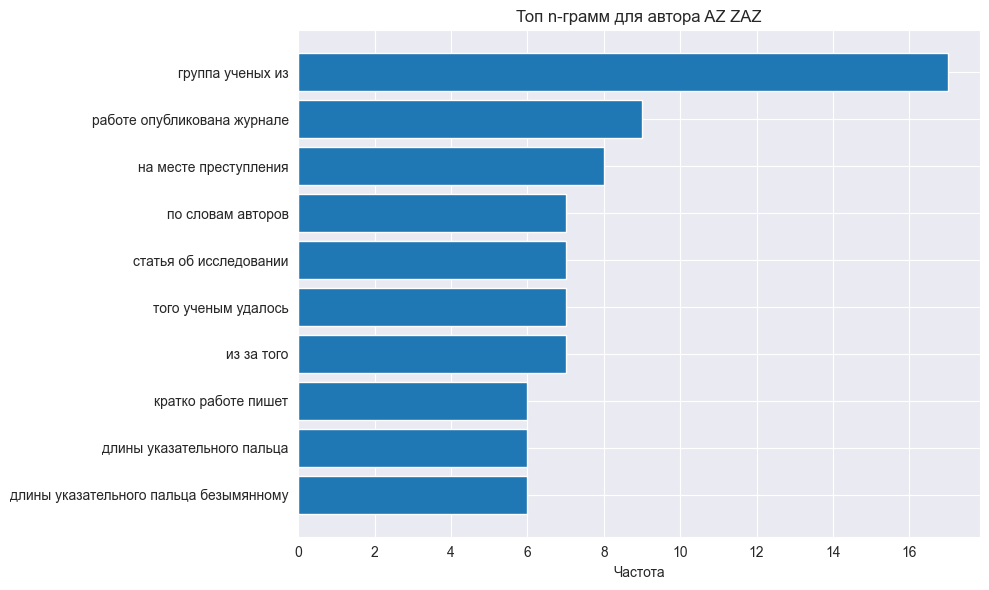

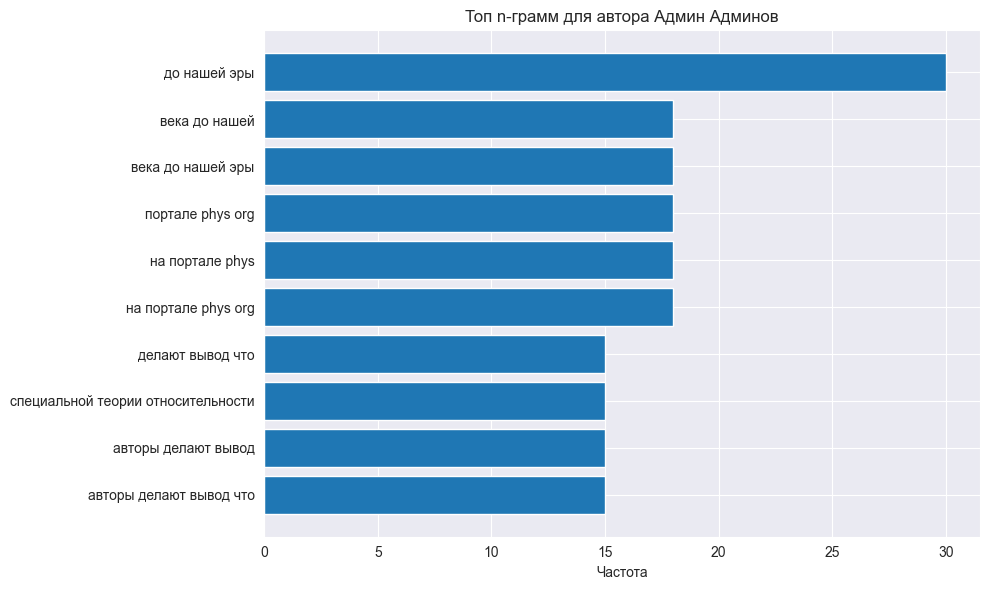

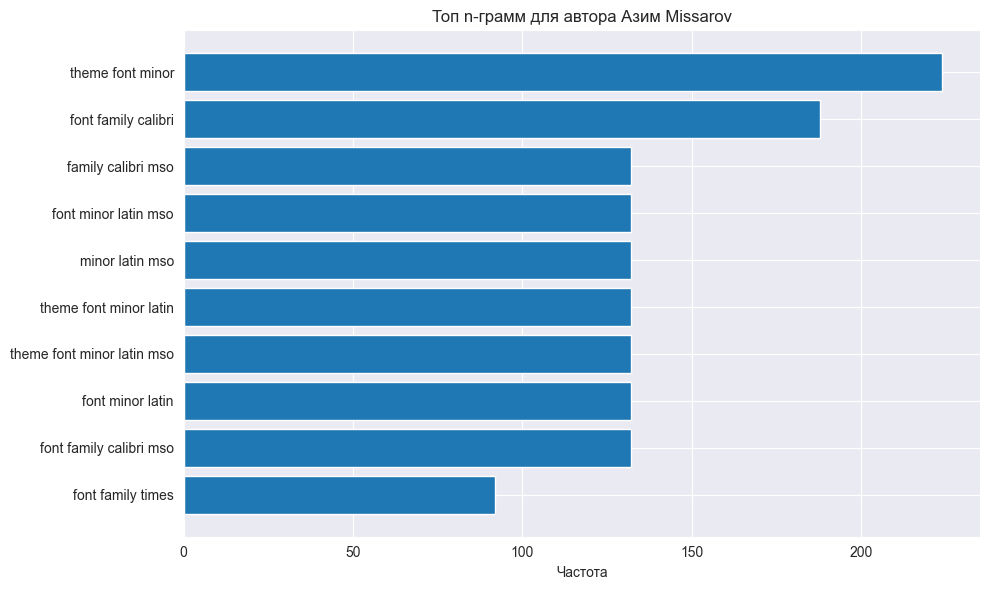

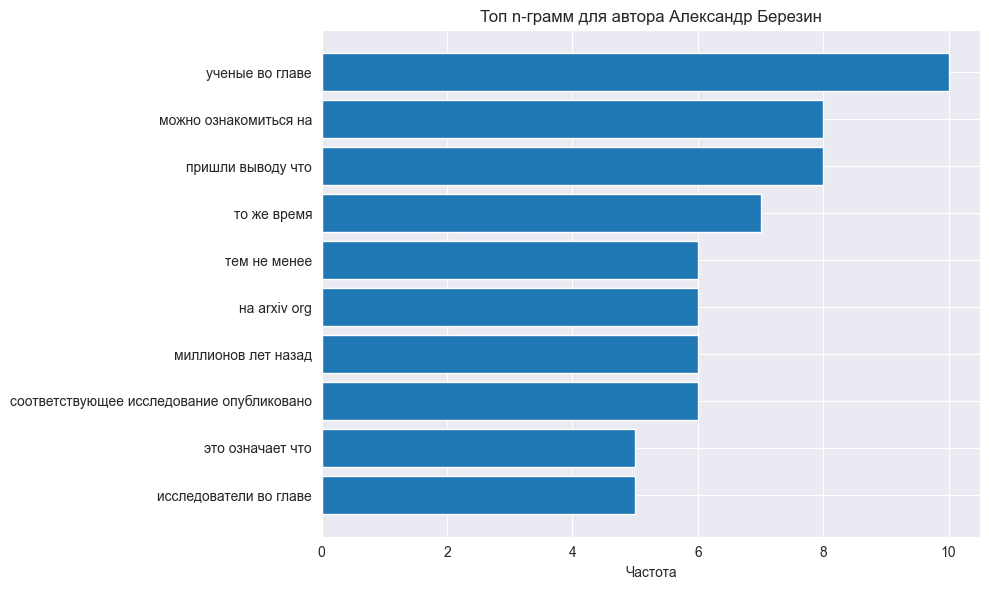

Обрабатываю 5 текстов автора: Азим Missarov
Обрабатываю 132 текстов автора: Александр Березин
Обрабатываю 75 текстов автора: Андрей Коняев
Обрабатываю 5 текстов автора: Артем Коржиманов
Обрабатываю 924 текстов автора: Владимир Королев
Обрабатываю 3 текстов автора: Игорь Иванов
Обрабатываю 578 текстов автора: Кристина Уласович
Обрабатываю 618 текстов автора: Олег Лищук
Обрабатываю 27 текстов автора: Юлия Минц


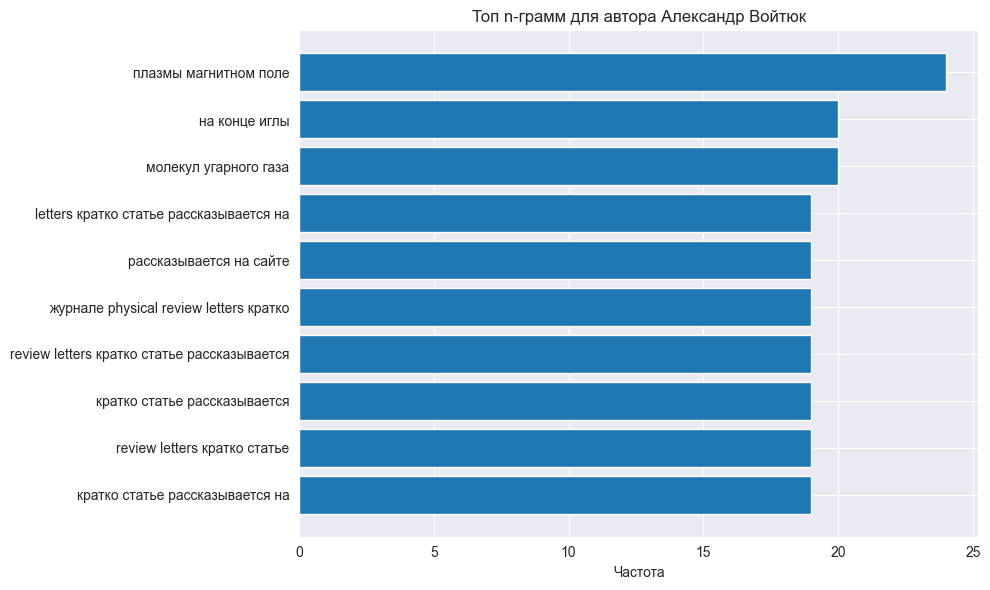

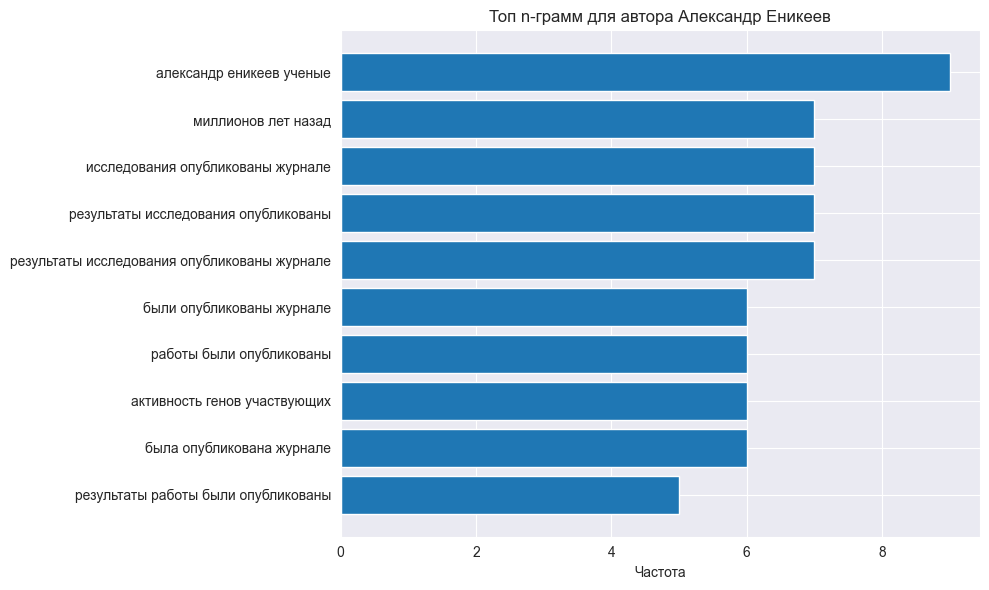

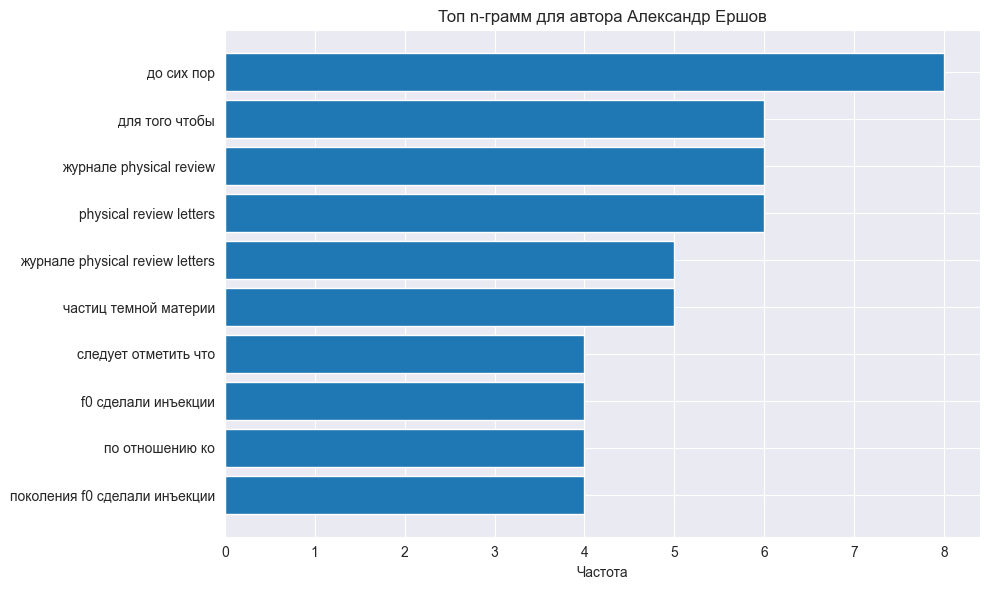

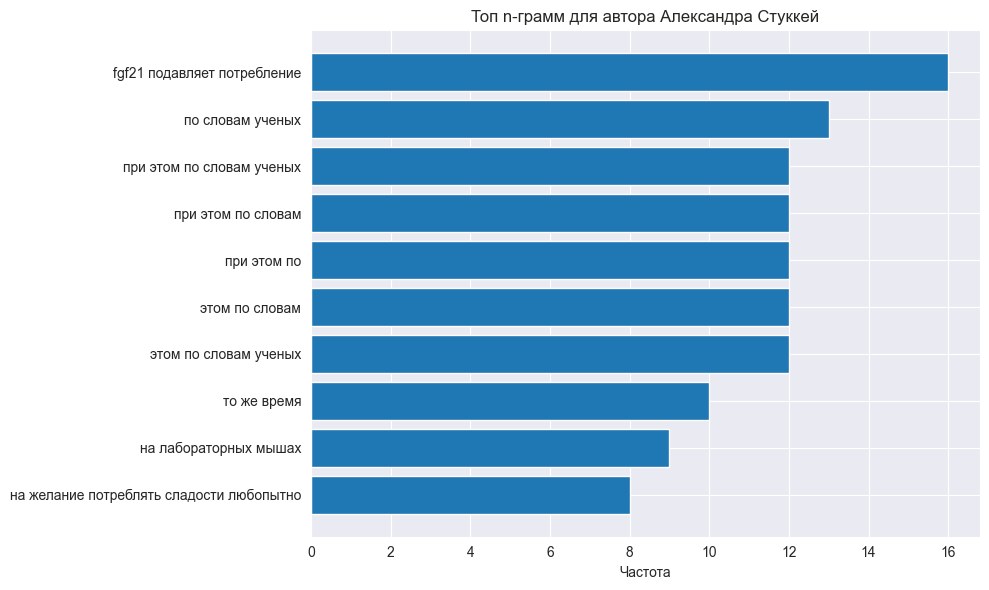

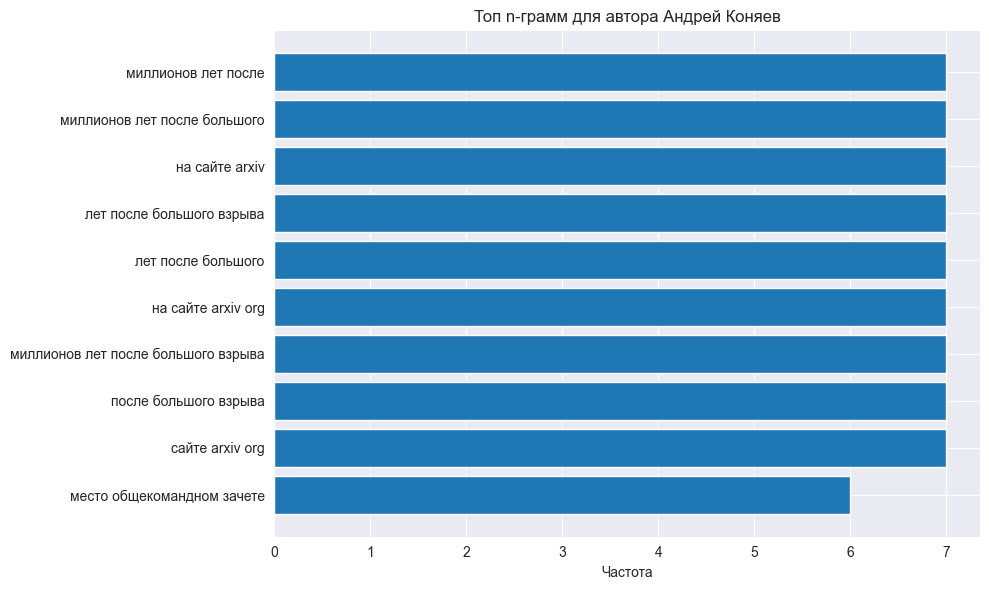

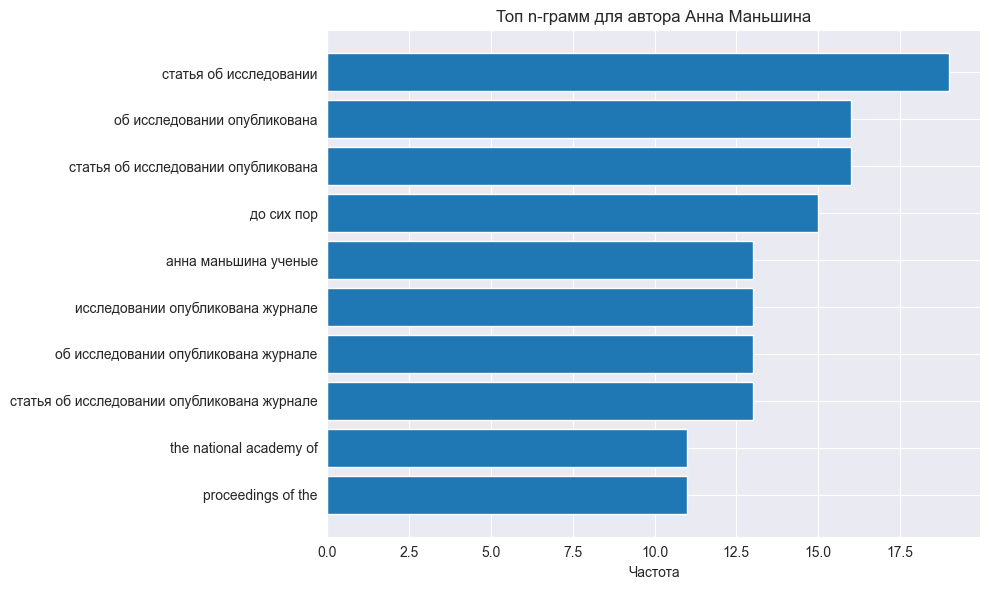

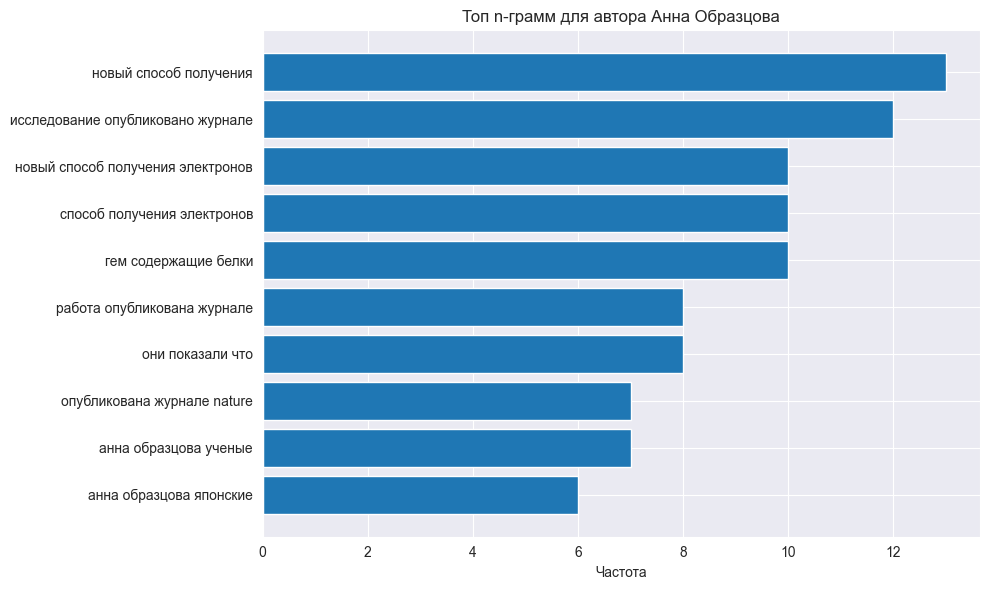

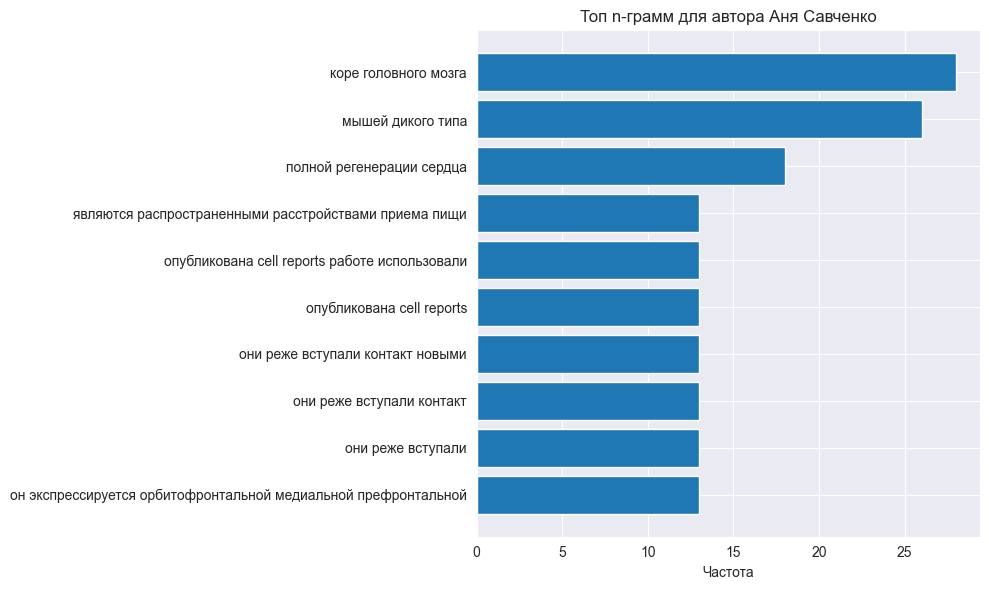

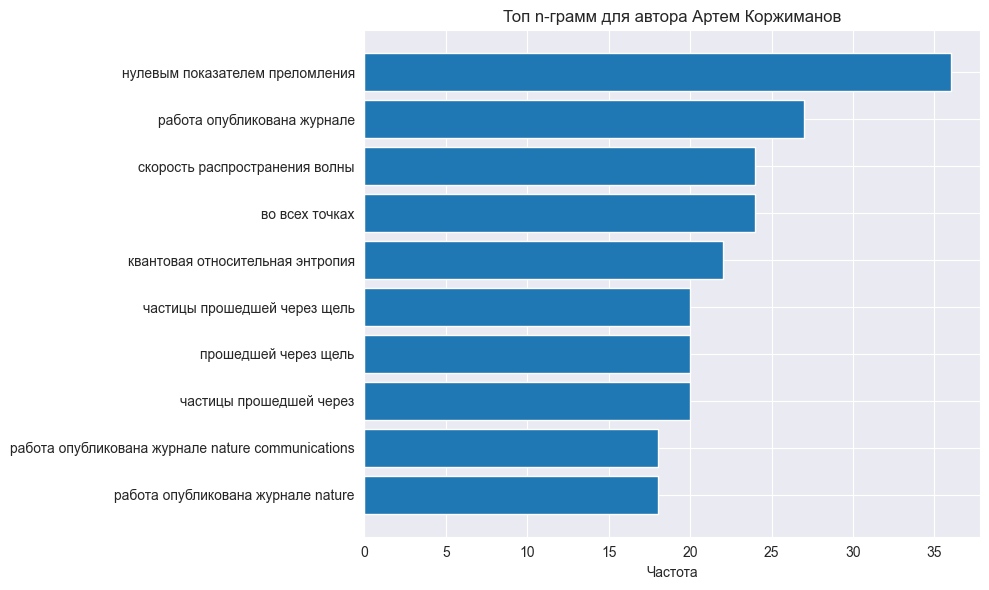

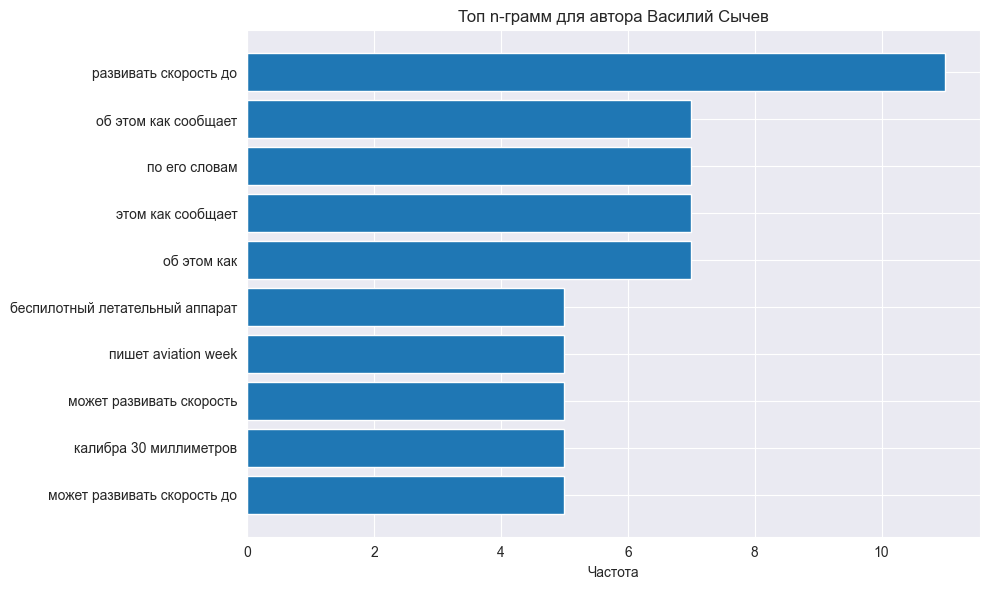

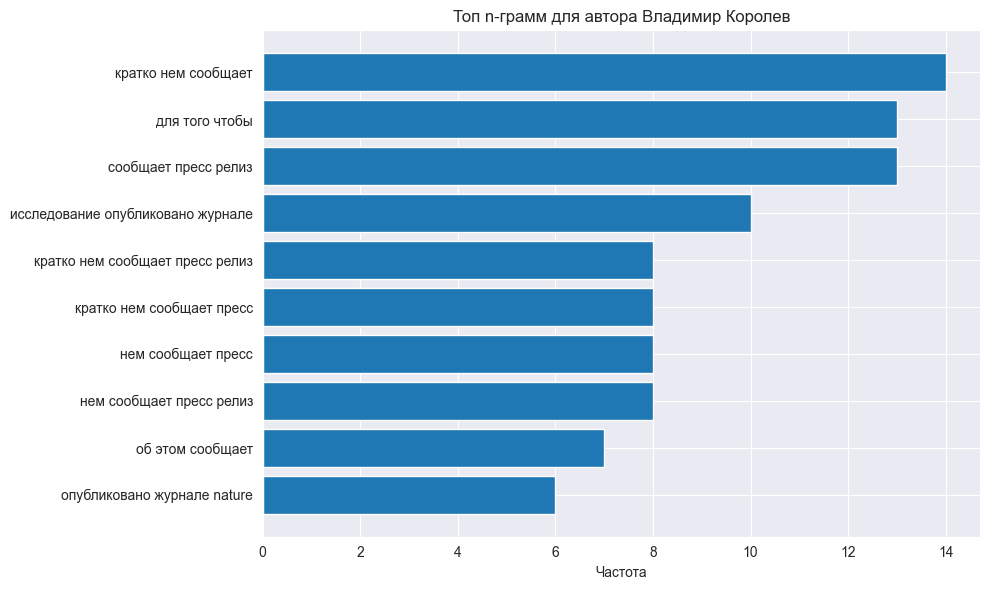

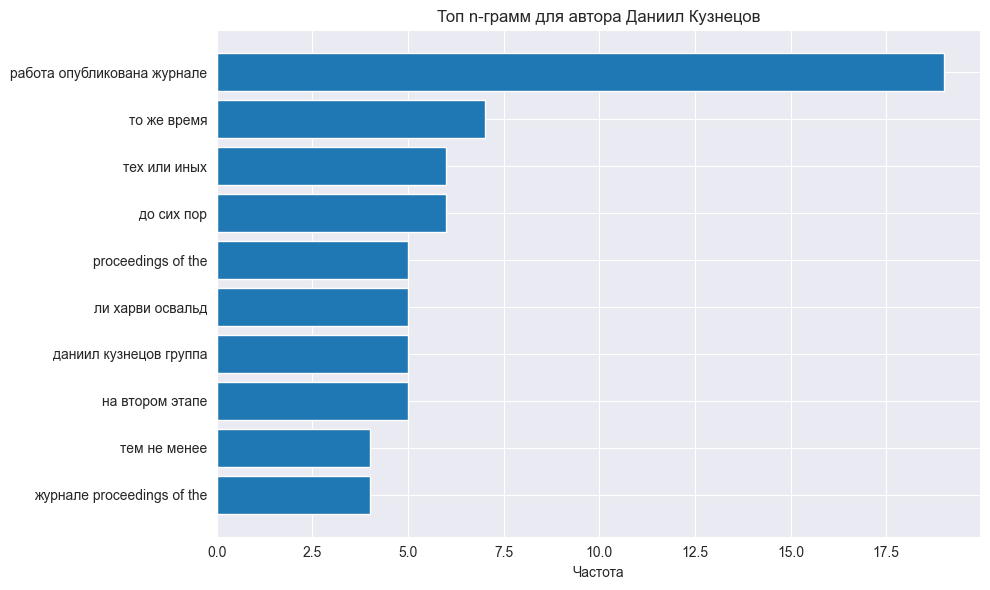

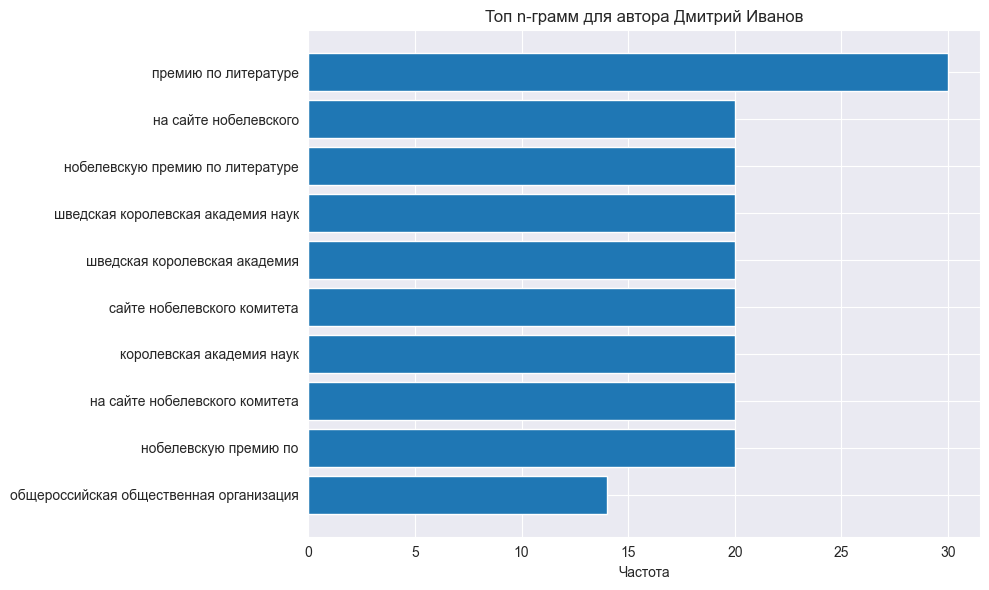

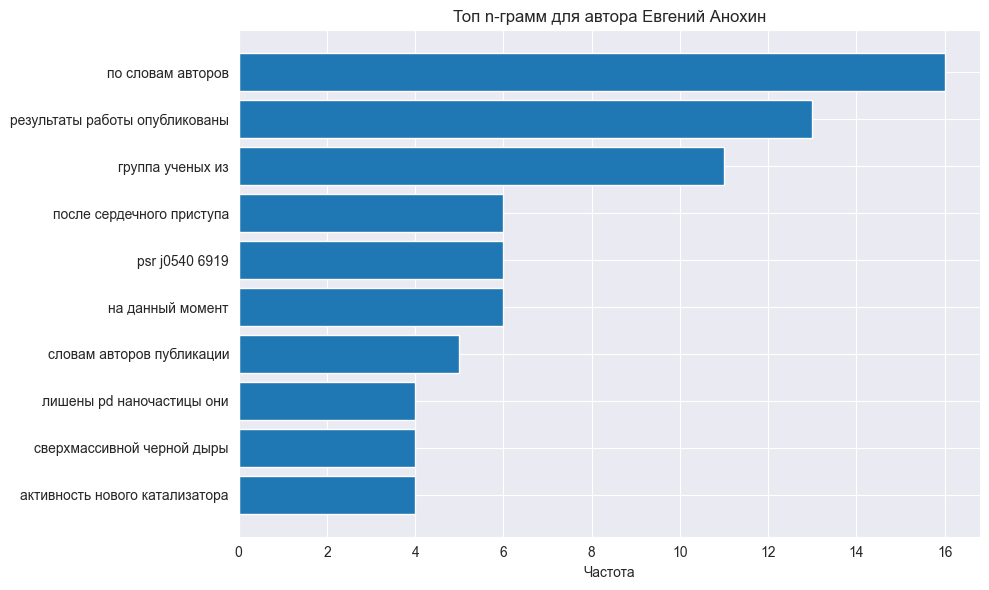

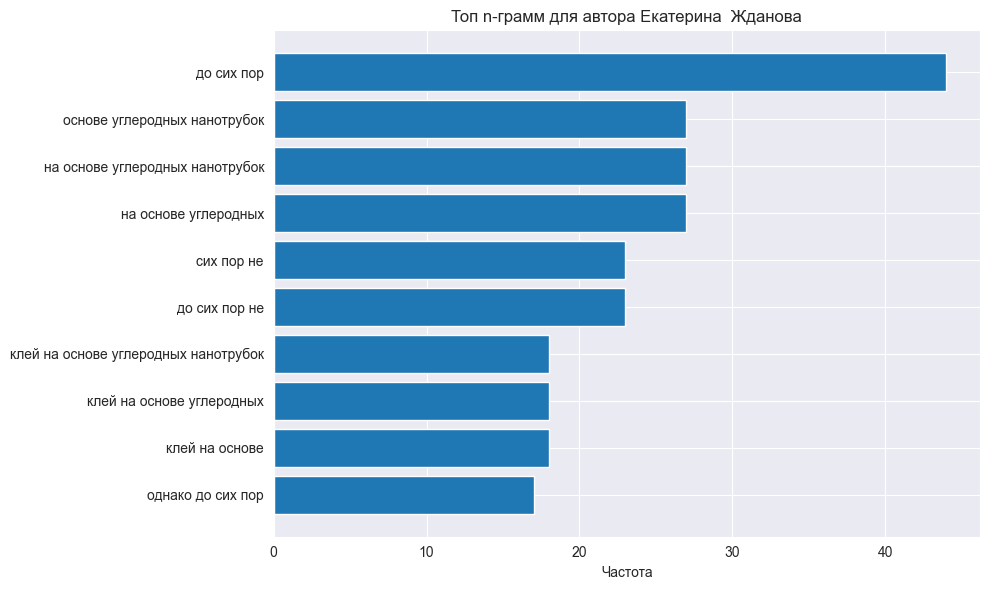

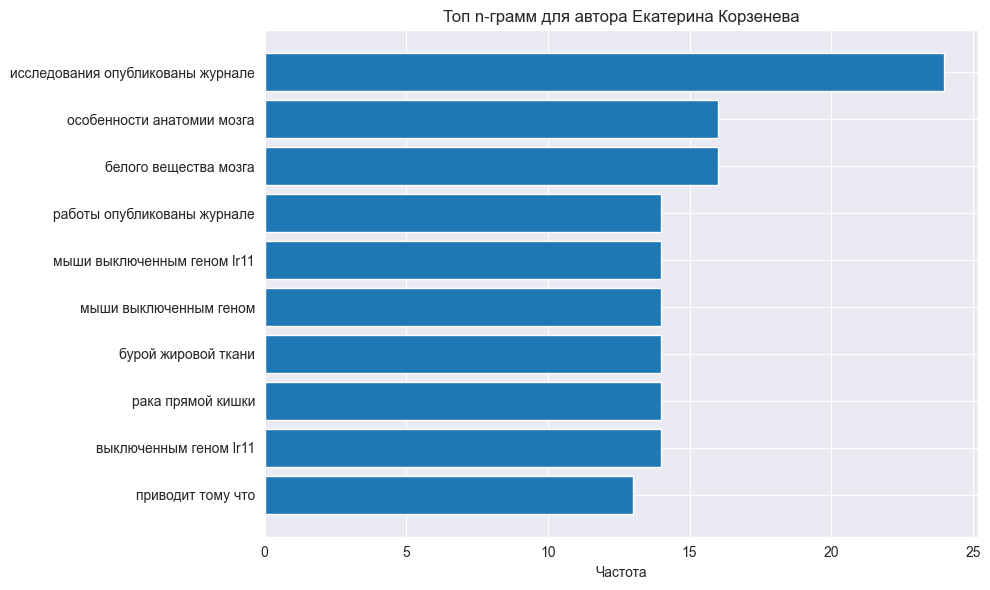

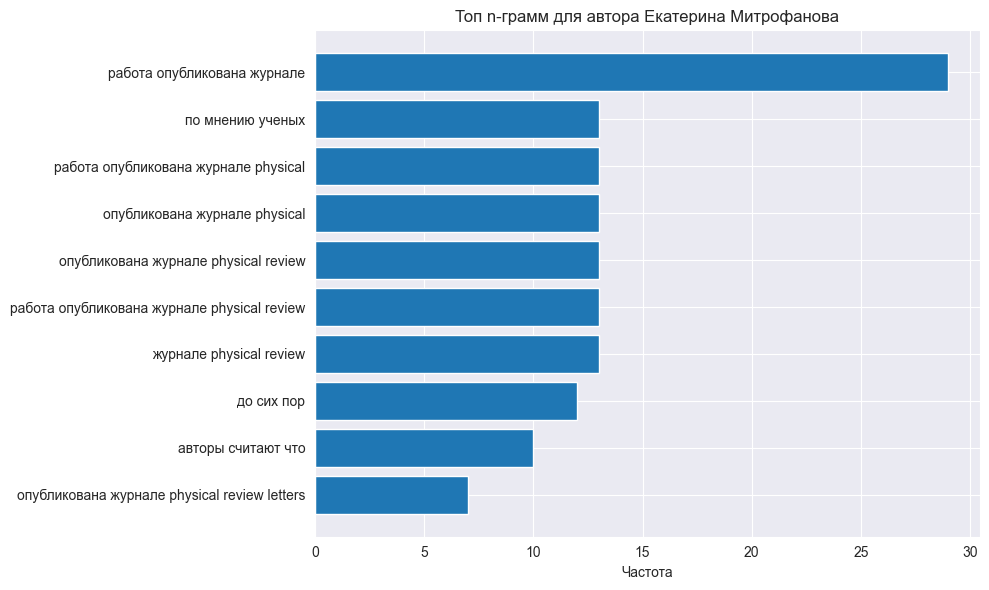

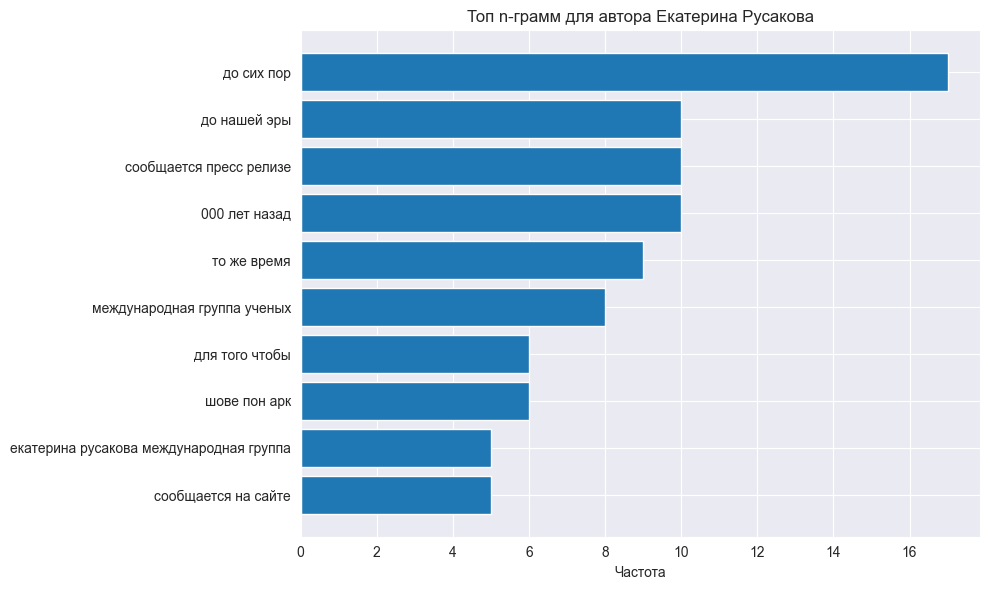

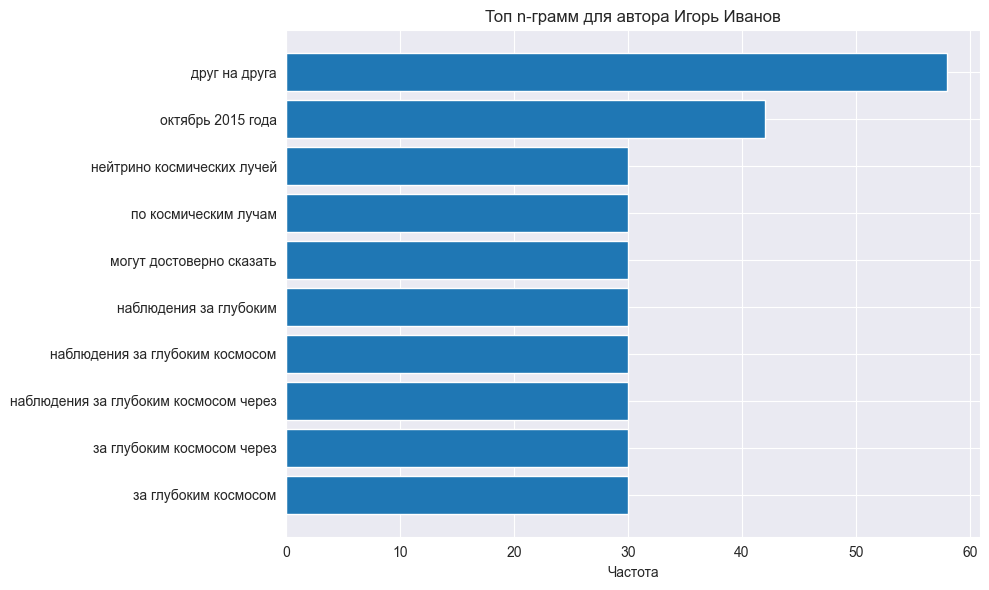

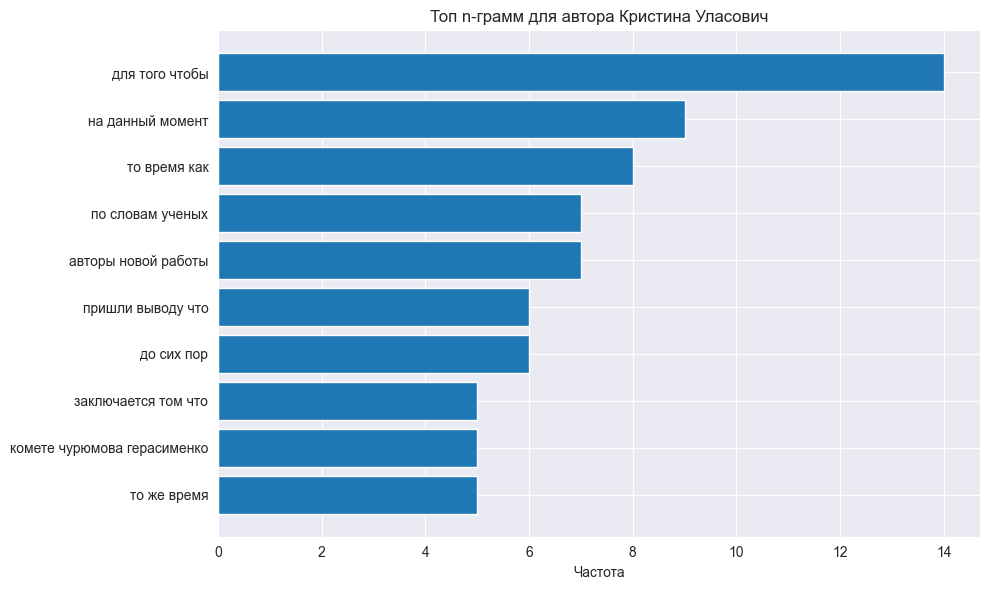

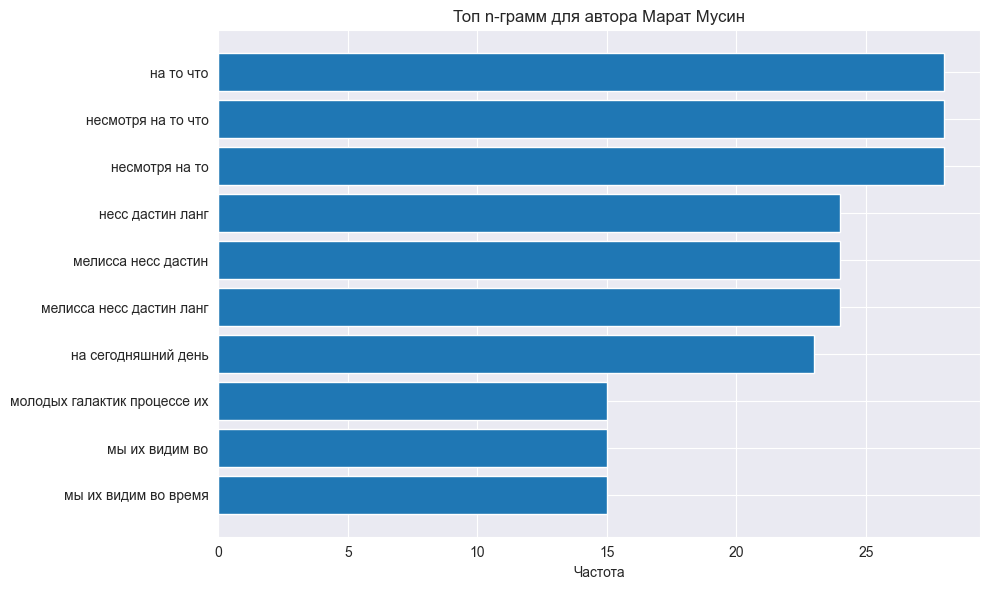

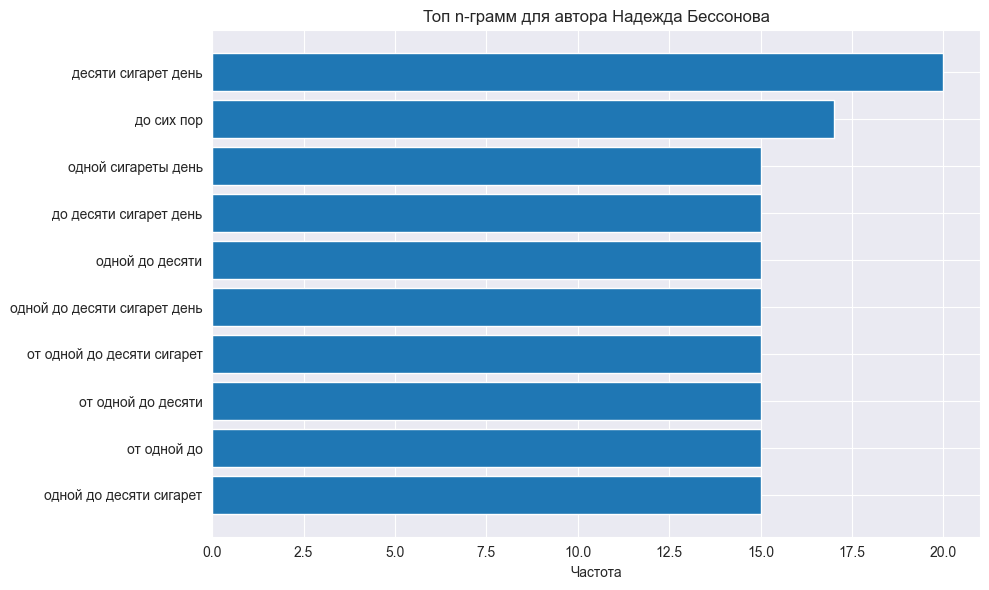

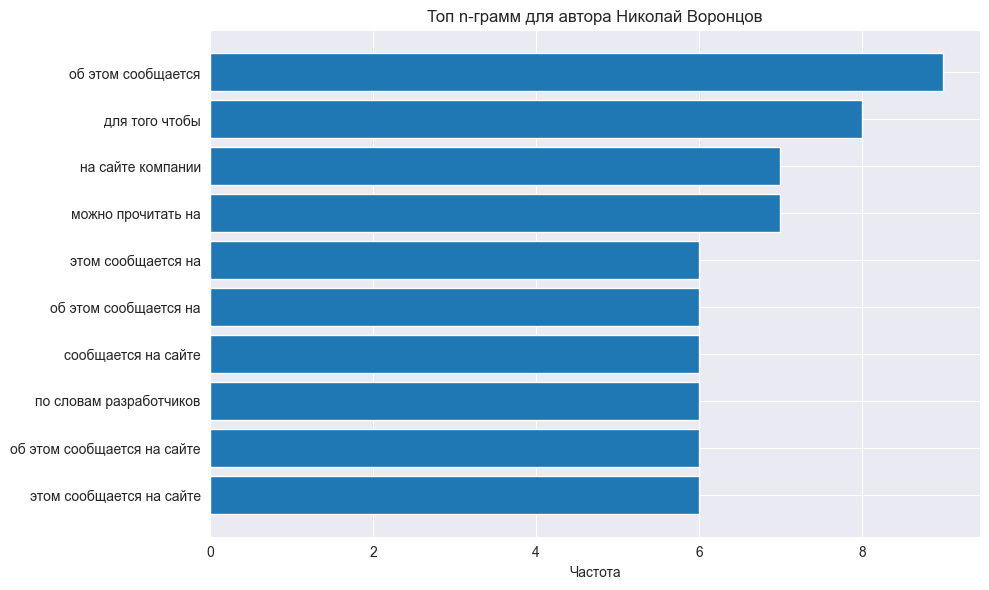

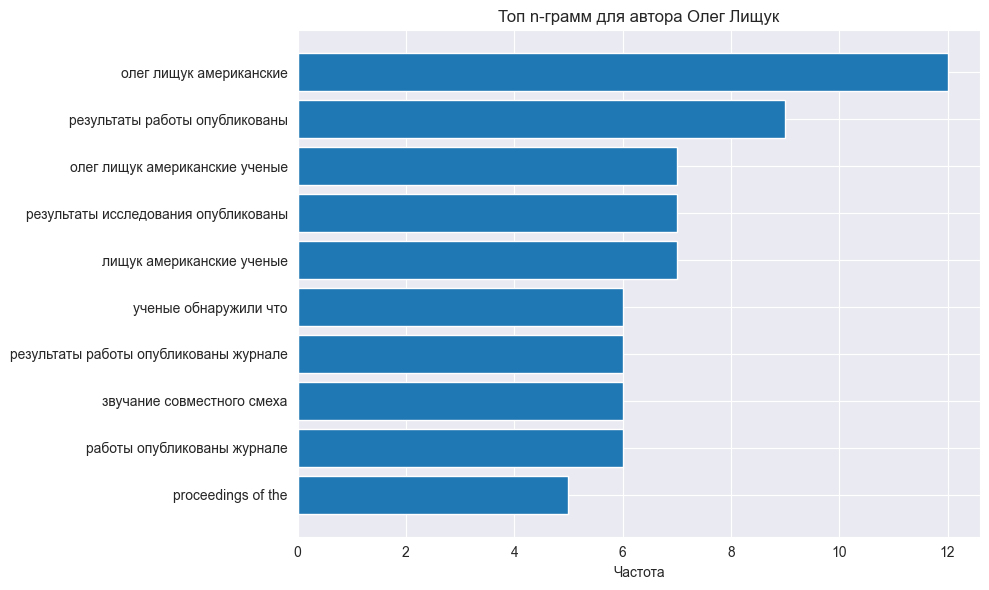

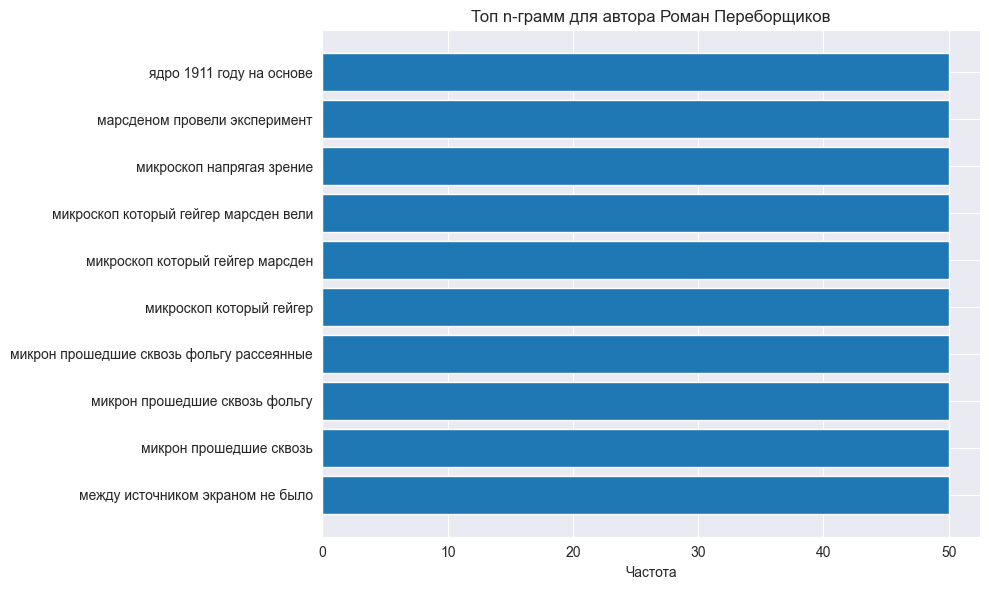

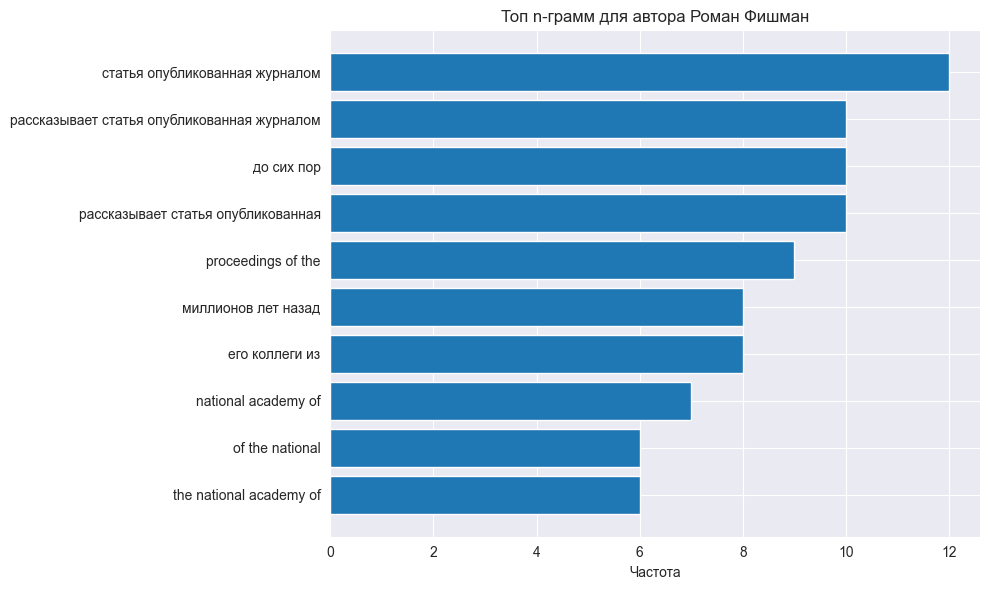

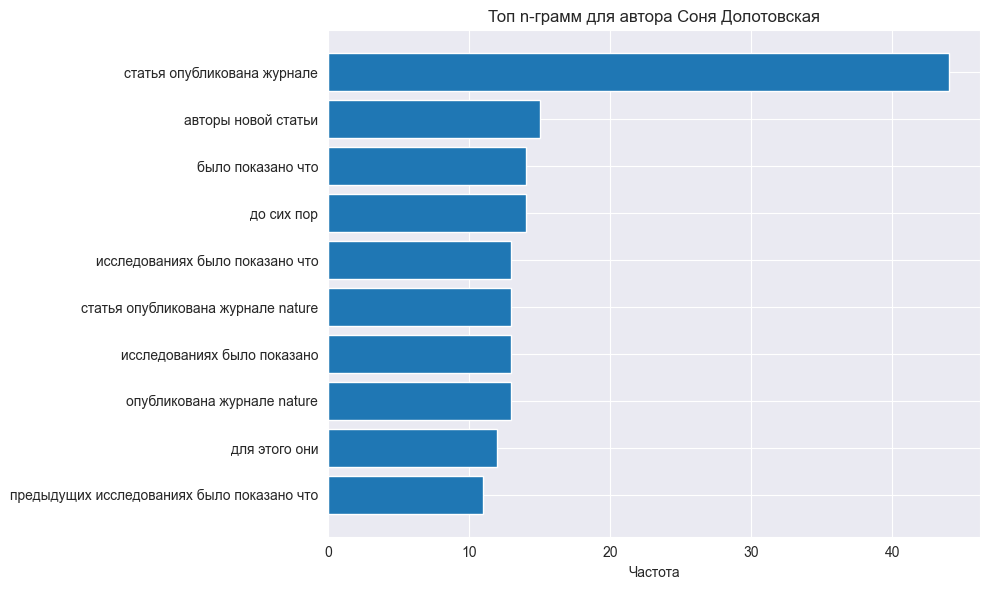

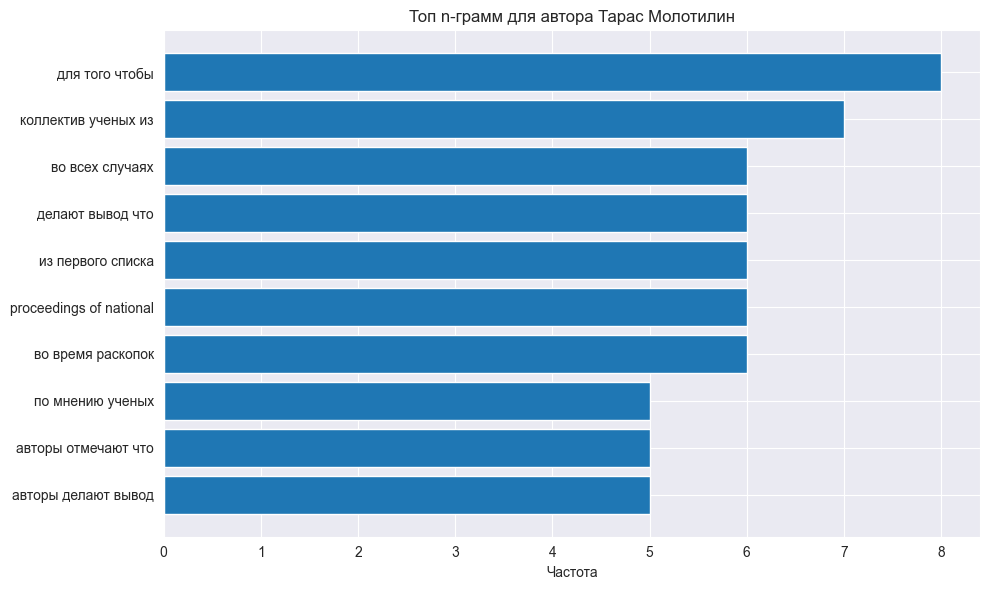

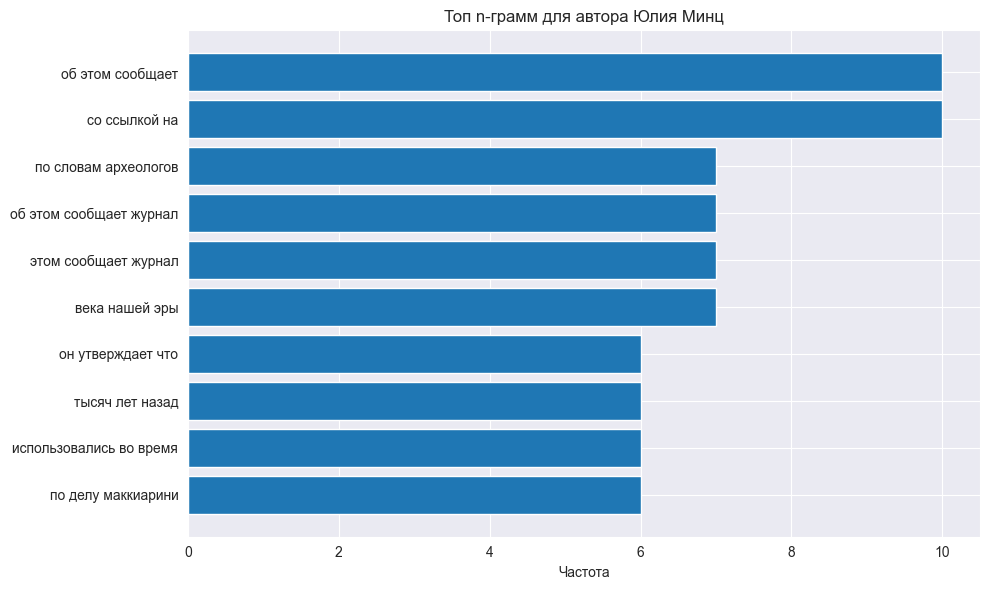

In [33]:
def plot_top_ngrams(ngrams_dict, author):
    data = ngrams_dict[author]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(data['ngrams'], data['counts'])
    ax.set_xlabel('Частота')
    ax.set_title(f'Топ n-грамм для автора {author}')
    ax.invert_yaxis()
    fig.tight_layout()

    display(fig)
    mlflow.log_figure(fig, f"plots/3_5_top_ngrams_{author}.png")
    plt.close(fig)

for author in ngrams_dict.keys():
    plot_top_ngrams(ngrams_dict, author)

In [ ]:
def find_unique_ngrams(df, ngram_range=(3,5)):

    authors = df['author'].unique()
    all_ngrams = {}

    for author in authors:
        author_text = ' '.join(df[df['author'] == author]['text'].tolist())
        vectorizer = CountVectorizer(ngram_range=ngram_range)
        ngram_matrix = vectorizer.fit_transform([author_text])
        ngram_counts = ngram_matrix.toarray().flatten()
        ngram_features = vectorizer.get_feature_names_out()

        all_ngrams[author] = set(ngram_features[ngram_counts > 0])

    unique_ngrams = {}
    for author in authors:
        other_authors_ngrams = set().union(*[all_ngrams[a] for a in authors if a != author])
        unique_ngrams[author] = all_ngrams[author] - other_authors_ngrams
        print(f"Автор {author}: {len(unique_ngrams[author])} уникальных n-грамм")
        print(f"Примеры: {list(unique_ngrams[author])[:10]}\n")

    return unique_ngrams

find_unique_ngrams(sample_df)

In [35]:
def is_data_normal(df, metric_name: str, a: float = 0.05) -> bool:
    _, p_normal_s = stats.shapiro(df[metric_name].dropna())
    if p_normal_s > 0.05:
        print(f"Данные по метрике {metric_name} нормально распределены ({p_normal_s})")
        return True
    else:
        print(f"Данные по метрике {metric_name} НЕ нормально распределены ({p_normal_s})")
        return False

In [36]:
normal_dist_dict = {}
for metric in METRICS_LIST:
    flag1 = is_data_normal(author_df, metric + '_mean')
    flag2 = is_data_normal(author_df, metric + '_median')
    normal_dist_dict[metric + '_mean'] = flag1
    normal_dist_dict[metric + '_median'] = flag2
    print()
mlflow.log_dict(normal_dist_dict, "data/normal_dist_dict.json")

Данные по метрике avg_sent_len_words_mean нормально распределены (0.37035013259109506)
Данные по метрике avg_sent_len_words_median НЕ нормально распределены (0.003338213182223897)

Данные по метрике avg_word_len_chars_mean нормально распределены (0.9843443578439035)
Данные по метрике avg_word_len_chars_median нормально распределены (0.8345168025039404)

Данные по метрике mtld_mean нормально распределены (0.23970910719756094)
Данные по метрике mtld_median нормально распределены (0.19547563720826514)

Данные по метрике avg_tree_depth_mean нормально распределены (0.4748579412809254)
Данные по метрике avg_tree_depth_median нормально распределены (0.3885296905815268)

Данные по метрике passive_ratio_mean нормально распределены (0.06613101054035636)
Данные по метрике passive_ratio_median НЕ нормально распределены (0.00904809284985169)

Данные по метрике func_word_ratio_mean нормально распределены (0.10939163047443175)
Данные по метрике func_word_ratio_median нормально распределены (0.0842018

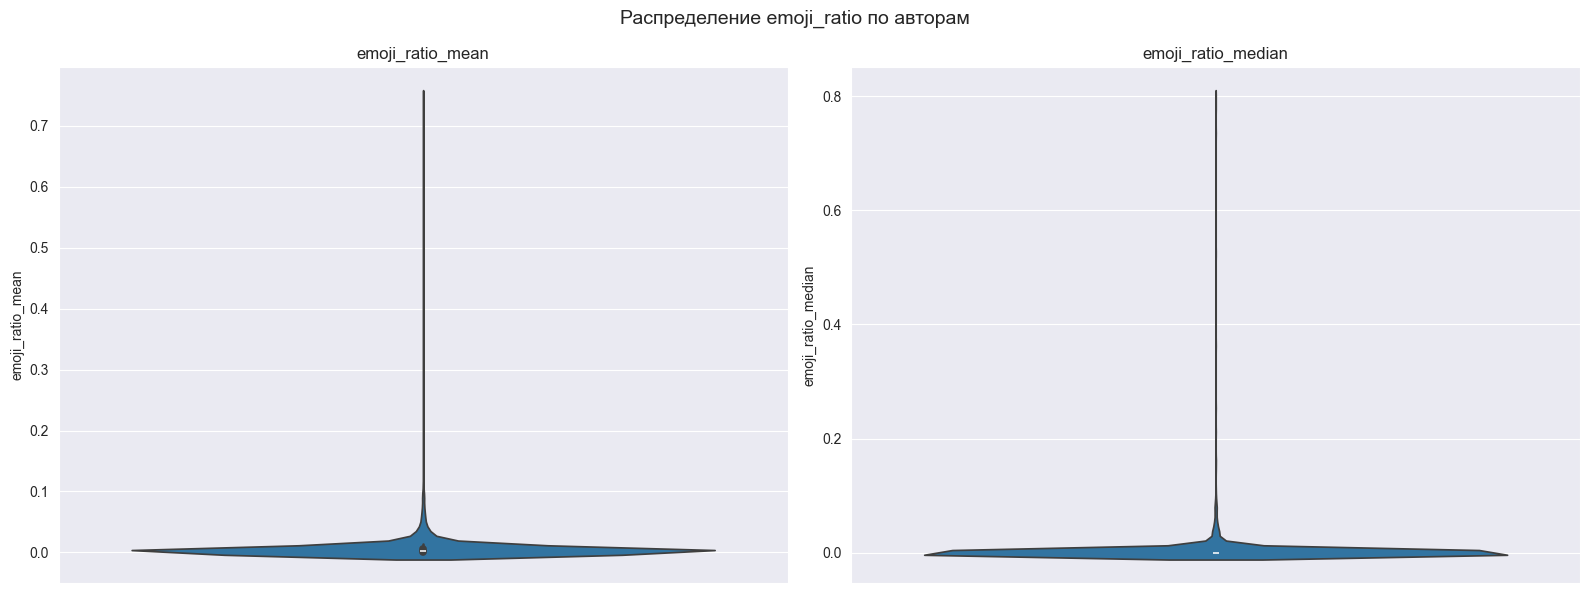

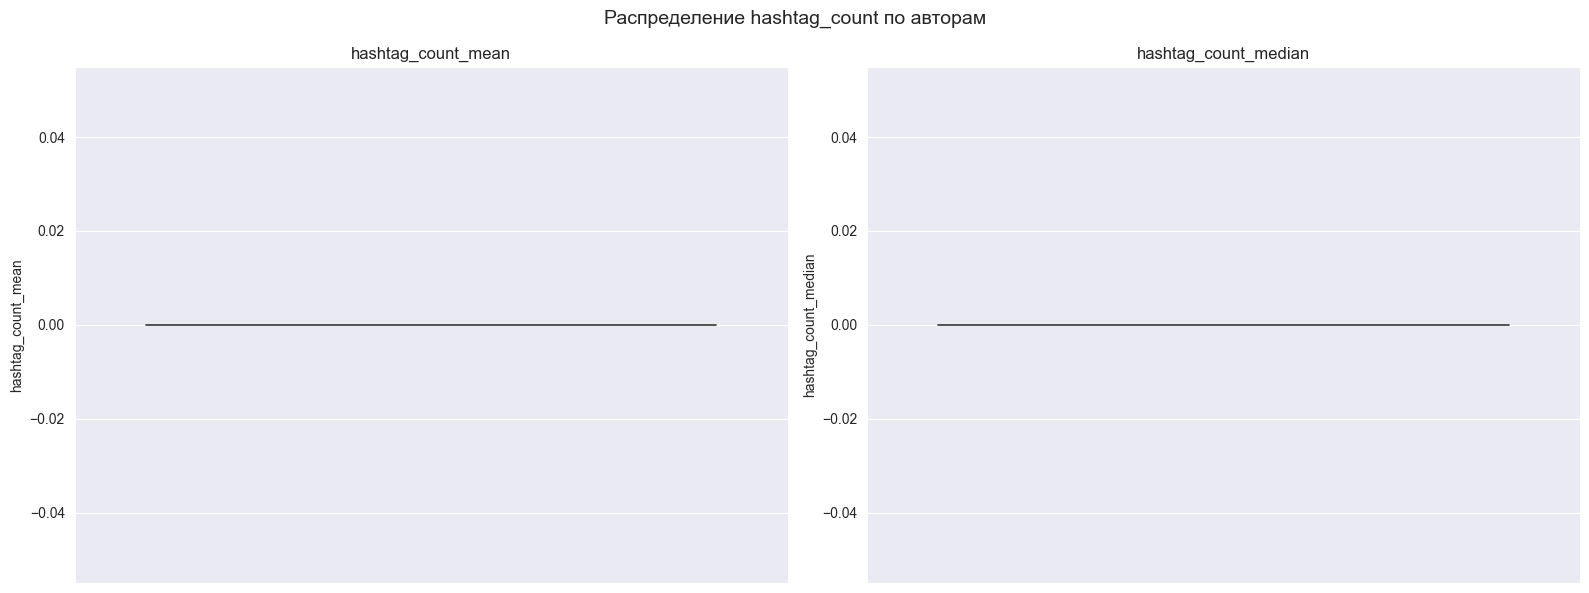

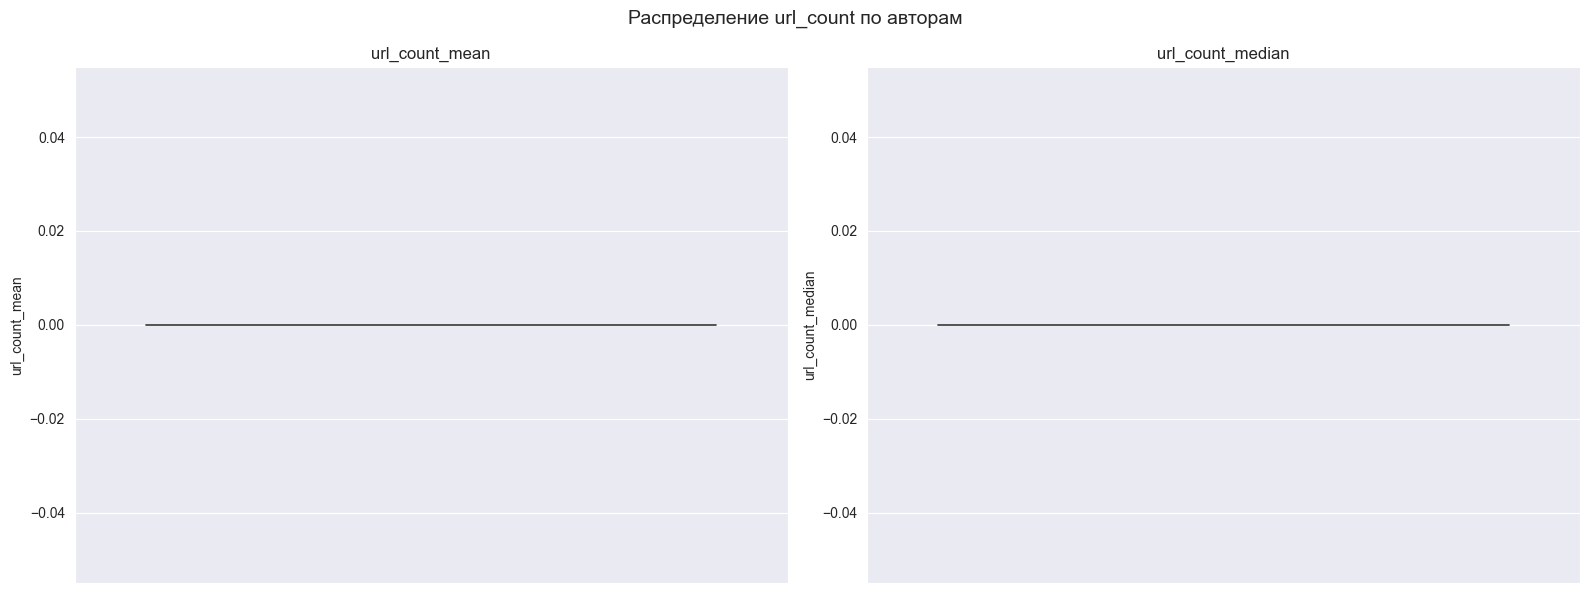

In [42]:
socials_metrics = [
    'emoji_ratio',
    'hashtag_count',
    'url_count'
]
for metric in socials_metrics:
    col_mean = f'{metric}_mean'
    col_median = f'{metric}_median'

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.violinplot(data=author_df, y=col_mean, ax=axes[0])
    axes[0].set_title(col_mean)
    sns.violinplot(data=author_df, y=col_median, ax=axes[1])
    axes[1].set_title(col_median)

    fig.suptitle(f'Распределение {metric} по авторам', fontsize=14)
    fig.tight_layout()

    display(fig)
    mlflow.log_figure(fig, f"plots/{metric}_violin.png")
    plt.close(fig)

In [37]:
mlflow.end_run()

🏃 View run first run at: http://localhost:2000/#/experiments/9/runs/01712f9f3c37472a963f1042d6402506
🧪 View experiment at: http://localhost:2000/#/experiments/9
